In [54]:
# Import required libraries for data analysis and visualization
import os, glob, pandas as pd, seaborn as sns, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

In [55]:
import re

# Load master heatmap CSV files from current directory
csv_files = glob.glob("master_heatmap*.csv")  # Find all CSV files in current directory

def extract_teff_bin(filename):
    match = re.search(r'(\d{4})_(\d{4})_K', filename)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    return None

# Load and combine all CSV files into a single dataframe, adding temperature bin
df = pd.DataFrame()
for f in csv_files:
    temp_bin = extract_teff_bin(f)
    temp_df = pd.read_csv(f)
    temp_df['teff_bin'] = temp_bin
    df = pd.concat([df, temp_df], ignore_index=True)

print(f"Combined dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())



Combined dataframe shape: (336, 7)
Columns: ['radius_bin_center', 'period_bin_center', 'detections', 'trials', 'transit_prob', 'detection_rate', 'teff_bin']
   radius_bin_center  period_bin_center  detections  trials  transit_prob  \
0               1.63           0.700000          32      39      0.242834   
1               1.63           1.213795          32      41      0.167226   
2               1.63           2.104076          28      41      0.120814   
3               1.63           3.647060          35      49      0.082521   
4               1.63           6.322136          17      33      0.056612   

   detection_rate   teff_bin  
0        0.820513  4000_4500  
1        0.780488  4000_4500  
2        0.682927  4000_4500  
3        0.714286  4000_4500  
4        0.515152  4000_4500  


Period values: [ 0.7         1.21379484  2.10407628  3.64706025  6.32213587 10.95991788
 19.00194256]
Period log values: [-0.15490196  0.08414529  0.32306148  0.56194294  0.80086383  1.0398073
  1.278798  ]
Period bin edges: [0.5315870791982804, 0.9217680774690752, 1.5980979107961888, 2.7701431313092457, 4.801792420547086, 8.324066913452322, 14.43120681207672, 25.020348313588052]
Number of bins: 7


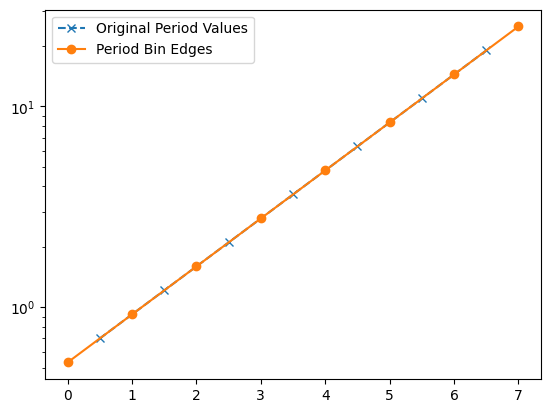

Radius values: [1.63       1.92029811 2.2627294  2.66604942 3.1408662  3.69995705]
Radius log values: [0.2121876  0.28336865 0.35463262 0.4258682  0.49704944 0.56819668]
Radius bin edges: [1.5017480601700404, 1.7692048822751023, 2.084493941393594, 2.45612467265326, 2.8937353874752607, 3.4089690583526253, 4.015783649123488]
Number of bins: 6


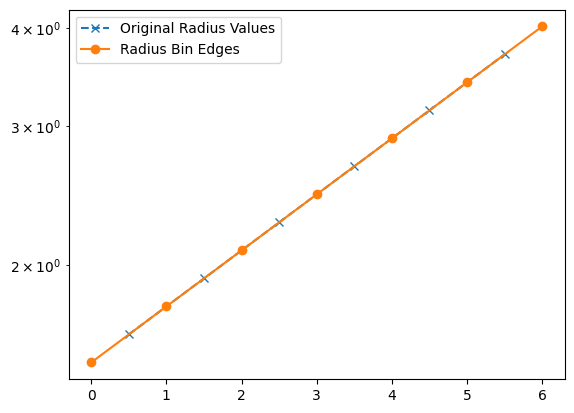

In [56]:
# Generate log-spaced bin edges for True Period values
period_vals = np.array(sorted(df['period_bin_center'].unique()))  # Get unique period values

# Calculate log-space halfway points between adjacent values
period_log = np.log10(period_vals)  # Convert to log space
period_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = period_log[1] - period_log[0]  # Log spacing between first two values
first_edge = 10**(period_log[0] - log_step/2)  # Extrapolate backward by half step
period_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(period_log) - 1):
    halfway_log = (period_log[i] + period_log[i+1]) / 2  # Midpoint in log space
    period_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = period_log[-1] - period_log[-2]  # Log spacing between last two values
last_edge = 10**(period_log[-1] + log_step/2)  # Extrapolate forward by half step
period_bin_edges.append(last_edge)

# Print results for verification
print(f"Period values: {period_vals}")
print(f"Period log values: {period_log}")
print(f"Period bin edges: {period_bin_edges}")
print(f"Number of bins: {len(period_bin_edges) - 1}")

# Plot to visualize period values vs bin edges
period_vals_x_axis = np.arange(len(period_vals)) + 0.5  # Offset for visualization
plt.plot(period_vals_x_axis, period_vals, 'x--', label='Original Period Values')
plt.plot(period_bin_edges, 'o-', label='Period Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()

# Generate log-spaced bin edges for True Radius values (same method as periods)
radius_vals = np.array(sorted(df['radius_bin_center'].unique()))  # Get unique radius values

# Calculate log-space halfway points between adjacent values
radius_log = np.log10(radius_vals)  # Convert to log space
radius_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = radius_log[1] - radius_log[0]  # Log spacing between first two values
first_edge = 10**(radius_log[0] - log_step/2)  # Extrapolate backward by half step
radius_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(radius_log) - 1):
    halfway_log = (radius_log[i] + radius_log[i+1]) / 2  # Midpoint in log space
    radius_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = radius_log[-1] - radius_log[-2]  # Log spacing between last two values
last_edge = 10**(radius_log[-1] + log_step/2)  # Extrapolate forward by half step
radius_bin_edges.append(last_edge)

# Print results for verification
print(f"Radius values: {radius_vals}")
print(f"Radius log values: {radius_log}")
print(f"Radius bin edges: {radius_bin_edges}")
print(f"Number of bins: {len(radius_bin_edges) - 1}")

# Plot to visualize radius values vs bin edges
radius_vals_x_axis = np.arange(len(radius_vals)) + 0.5  # Offset for visualization
plt.plot(radius_vals_x_axis, radius_vals, 'x--', label='Original Radius Values')
plt.plot(radius_bin_edges, 'o-', label='Radius Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()



In [57]:
# Assign bin min/max edges for each row using pd.cut with labels as bin index, then map to edge values
df['radius_bin'] = pd.cut(df['radius_bin_center'], bins=radius_bin_edges, include_lowest=True, labels=False)
df['period_bin'] = pd.cut(df['period_bin_center'], bins=period_bin_edges, include_lowest=True, labels=False)
df['radius_bin_min'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['radius_bin_max'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
df['period_bin_min'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['period_bin_max'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
print(df.head())

   radius_bin_center  period_bin_center  detections  trials  transit_prob  \
0               1.63           0.700000          32      39      0.242834   
1               1.63           1.213795          32      41      0.167226   
2               1.63           2.104076          28      41      0.120814   
3               1.63           3.647060          35      49      0.082521   
4               1.63           6.322136          17      33      0.056612   

   detection_rate   teff_bin  radius_bin  period_bin  radius_bin_min  \
0        0.820513  4000_4500           0           0        1.501748   
1        0.780488  4000_4500           0           1        1.501748   
2        0.682927  4000_4500           0           2        1.501748   
3        0.714286  4000_4500           0           3        1.501748   
4        0.515152  4000_4500           0           4        1.501748   

   radius_bin_max  period_bin_min  period_bin_max  
0        1.769205        0.531587        0.921768  


786
688


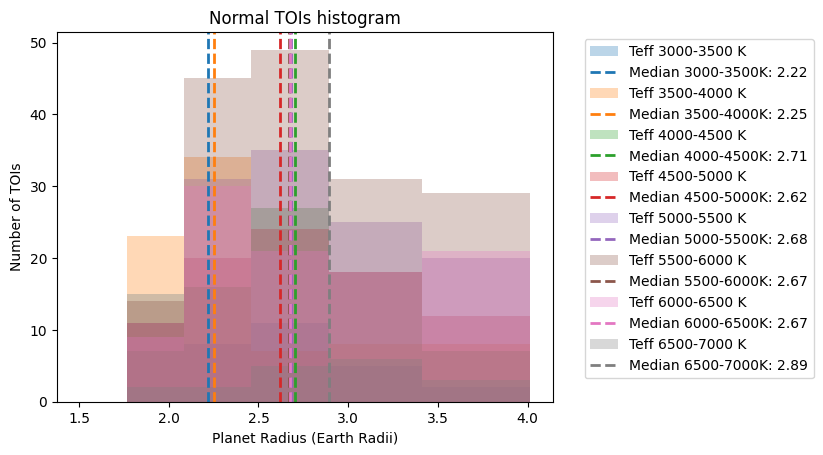

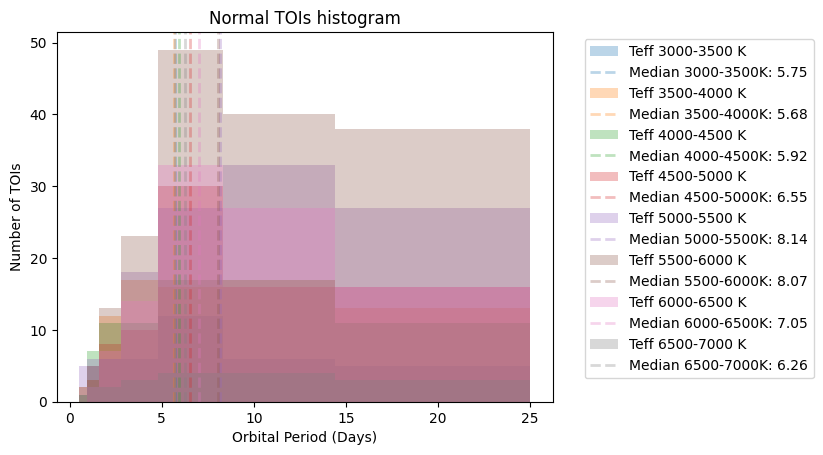

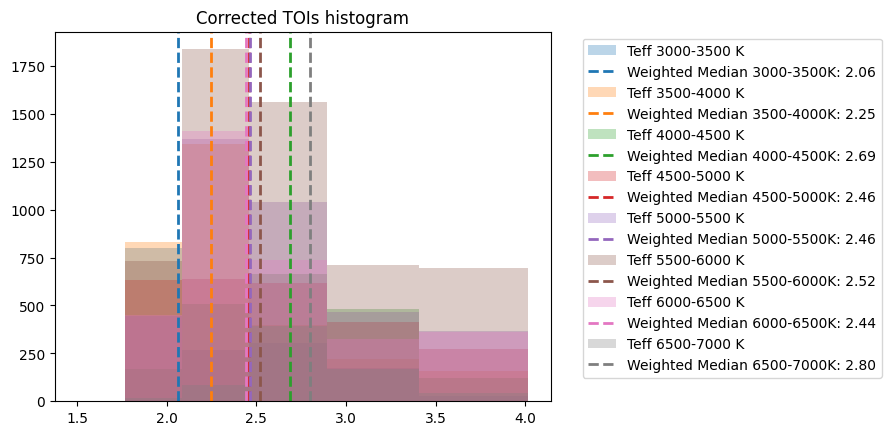

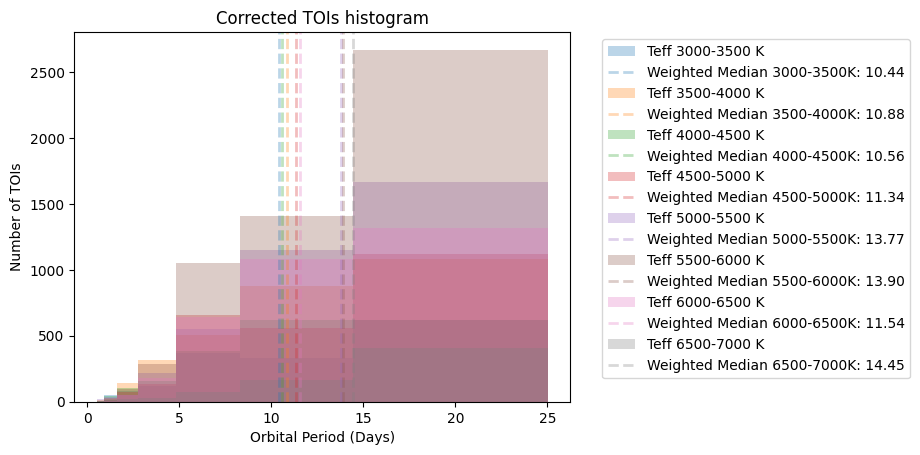

Rows with any NaNs in merged_df: 0
Rows with NaNs in merged_df:
Empty DataFrame
Columns: [toi, st_teff, pl_rade, pl_orbper, teff_bin, radius_bin_min, radius_bin_max, period_bin_min, period_bin_max, radius_bin_center, period_bin_center, detections, trials, transit_prob, detection_rate, radius_bin, period_bin, detection_inverse, transit_inverse, weight]
Index: []
         toi  st_teff   pl_rade  pl_orbper   teff_bin  radius_bin_min  \
0    5165.01  4642.10  3.300100   3.577501  4500_5000        2.893735   
1    6944.01  5181.10  2.609860  12.302750  5000_5500        2.456125   
2    5789.01  5132.00  2.537040  12.925605  5000_5500        2.456125   
3    5319.01  3580.00  3.746810   4.078527  3500_4000        3.408969   
4    5082.01  5670.00  2.643010   4.240354  5500_6000        2.456125   
..       ...      ...       ...        ...        ...             ...   
683  1802.01  3859.00  2.506646  16.796111  3500_4000        2.456125   
684  2265.01  5951.67  2.479919   0.829408  5500_600

In [58]:
 
TOIs = pd.read_csv('../TOI_Mar2025_1pt5to4_R_detected_real_only.csv')

# Define temperature ranges matching our completeness data
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

#teff_ranges = [(t, t + 1000) for t in range(3000, 7000, 1000)]

# Filter TOIs data
TOIs_filtered = TOIs.dropna(subset=['st_teff', 'pl_rade'])
print(len(TOIs_filtered))

TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_rade'] > 1.8) & (TOIs_filtered['pl_rade'] < 4.0)]
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_orbper'] > 0.531) & (TOIs_filtered['pl_orbper'] < 25.1)]
#TOIs_bootstrap = TOIs_bootstrap[~TOIs_bootstrap['toi'].isin([2194.01])] #second try ones with giant corrections

#TOIs_filtered = TOIs_filtered[~TOIs_filtered['id'].isin([80224448, 370009806])] # The ones with giant corrections
#TOIs_filtered = TOIs_filtered[~TOIs_filtered['toi'].isin([2482.01, 2194.01, 2103.02])] #second try ones with giant corrections
#TOIs_filtered = TOIs_filtered[~TOIs_filtered['toi'].isin([2194.01])] #second try ones with giant corrections
TOIs_filtered = TOIs_filtered[TOIs_filtered['tfopwg_disp'] != 'FA']


#TOIs_filtered = TOIs_filtered[(TOIs_filtered['ruwe'] <= 1.4)]

# Remove false positives if column exists
if 'tfopwg_disp' in TOIs_filtered.columns:
    TOIs_filtered = TOIs_filtered[TOIs_filtered['tfopwg_disp'] != 'FP']

TOIs_filtered = TOIs_filtered[['toi', 'st_teff', 'pl_rade', 'pl_orbper']]

radius_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]

period_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]
print(len(TOIs_filtered))

#print(radius_bins)
#print(period_bins)

for row in TOIs_filtered.itertuples():
    teff = row.st_teff
    radius = row.pl_rade
    period = row.pl_orbper
    
    # Determine which temperature bin the TOI falls into
    for teff_min, teff_max in teff_ranges:
        if teff_min <= teff < teff_max:
            teff_bin = f"{teff_min}_{teff_max}"
            TOIs_filtered.at[row.Index, 'teff_bin'] = teff_bin
    
    for rad_min, rad_max in radius_bins:
        if rad_min <= radius < rad_max:
            radius_bin_min = rad_min
            radius_bin_max = rad_max
            TOIs_filtered.at[row.Index, 'radius_bin_min'] = radius_bin_min
            TOIs_filtered.at[row.Index, 'radius_bin_max'] = radius_bin_max

    for per_min, per_max in period_bins:
        if per_min <= period < per_max:
            period_bin_min = per_min
            period_bin_max = per_max
            TOIs_filtered.at[row.Index, 'period_bin_min'] = period_bin_min
            TOIs_filtered.at[row.Index, 'period_bin_max'] = period_bin_max

#print(TOIs_filtered)
  
# Merge TOIs with completeness data
merged_df = pd.merge(TOIs_filtered, df, on=['teff_bin', 'radius_bin_min', 'radius_bin_max', 'period_bin_min', 'period_bin_max'], how='left')
#print(merged_df)

#### REGULAR HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_rade'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Planet Radius (Earth Radii)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3, label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_orbper'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()
########

# calculate inverse detection and transit probabilities
for row in merged_df.itertuples():
    detection_rate = row.detection_rate
    transit_prob = row.transit_prob

    # Only update detection_inverse and transit_inverse, leave other columns untouched
    if pd.notnull(detection_rate) and detection_rate > 0:
        merged_df.at[row.Index, 'detection_inverse'] = 1/detection_rate
    else:
        merged_df.at[row.Index, 'detection_inverse'] = np.nan

    if pd.notnull(transit_prob) and transit_prob > 0:
        merged_df.at[row.Index, 'transit_inverse'] = 1/transit_prob
    else:
        merged_df.at[row.Index, 'transit_inverse'] = np.nan
#print(merged_df)

#merged_df to csv
#merged_df[['toi', 'detection_inverse', 'transit_inverse']].to_csv('merged_df.csv', index=False)

# Duplicate each row of merged_df according to a per-row count value in a new column 'row_count'
# First, define how you want to calculate 'weight' for each row. 
# Example: here we use detection_inverse * transit_inverse rounded to nearest int, but you can change this logic.
merged_df['weight'] = (merged_df['detection_inverse'] * merged_df['transit_inverse']).fillna(1)
#merged_df['mult_count'] = np.where(merged_df['mult_count'] >= 1, merged_df['mult_count'] - 1, merged_df['mult_count'])
#print(merged_df[['toi', 'detection_rate', 'transit_prob', 'detection_inverse', 'transit_inverse', 'mult_count']])

#print(merged_df)
#print(merged_df[['toi', 'detection_inverse', 'transit_inverse', 'row_count']])
# Now repeat each row according to its 'row_count' value
#merged_df_corrected = merged_df#.loc[merged_df.index.repeat(merged_df['mult_count'])].reset_index(drop=True)

radius_medians = pd.DataFrame(columns=['Teff Range', 'Weighted Median Radius (Earth Radii)'])
###CORRECTED HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        radius_medians = pd.concat([
            radius_medians,
            pd.DataFrame({
            'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
            'Weighted Median Radius (Earth Radii)': [weighted_median]
            })], ignore_index=True)
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Corrected TOIs histogram')
plt.show()

#radius_medians.to_csv('corrected_medians.csv', index=False)

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Corrected TOIs histogram')
plt.show()
#######

#print how many rows have NaNs in merged_df
print("Rows with any NaNs in merged_df:", merged_df.isnull().any(axis=1).sum())
print("Rows with NaNs in merged_df:")
print(merged_df[merged_df.isnull().any(axis=1)])
print(merged_df)

toi                  122.01     175.02     210.01     218.02      256.01   \
radius_bin_center                                                           
1.920390            0.000000   0.000000   0.000000  56.453983  157.595433   
2.262692            0.000000   0.000000  58.291738   0.000000    0.000000   
2.665966           29.737288   0.000000   0.000000   0.000000    0.000000   
3.140805            0.000000  26.604361   0.000000   0.000000    0.000000   
3.699957            0.000000   0.000000   0.000000   0.000000    0.000000   

toi                  406.01    521.01    654.01     700.01     732.02   ...  \
radius_bin_center                                                       ...   
1.920390           56.453983  9.966407  0.000000   0.000000   0.000000  ...   
2.262692            0.000000  0.000000  0.000000   0.000000  58.291738  ...   
2.665966            0.000000  0.000000  9.287006  72.476879   0.000000  ...   
3.140805            0.000000  0.000000  0.000000   0.000000   0.0

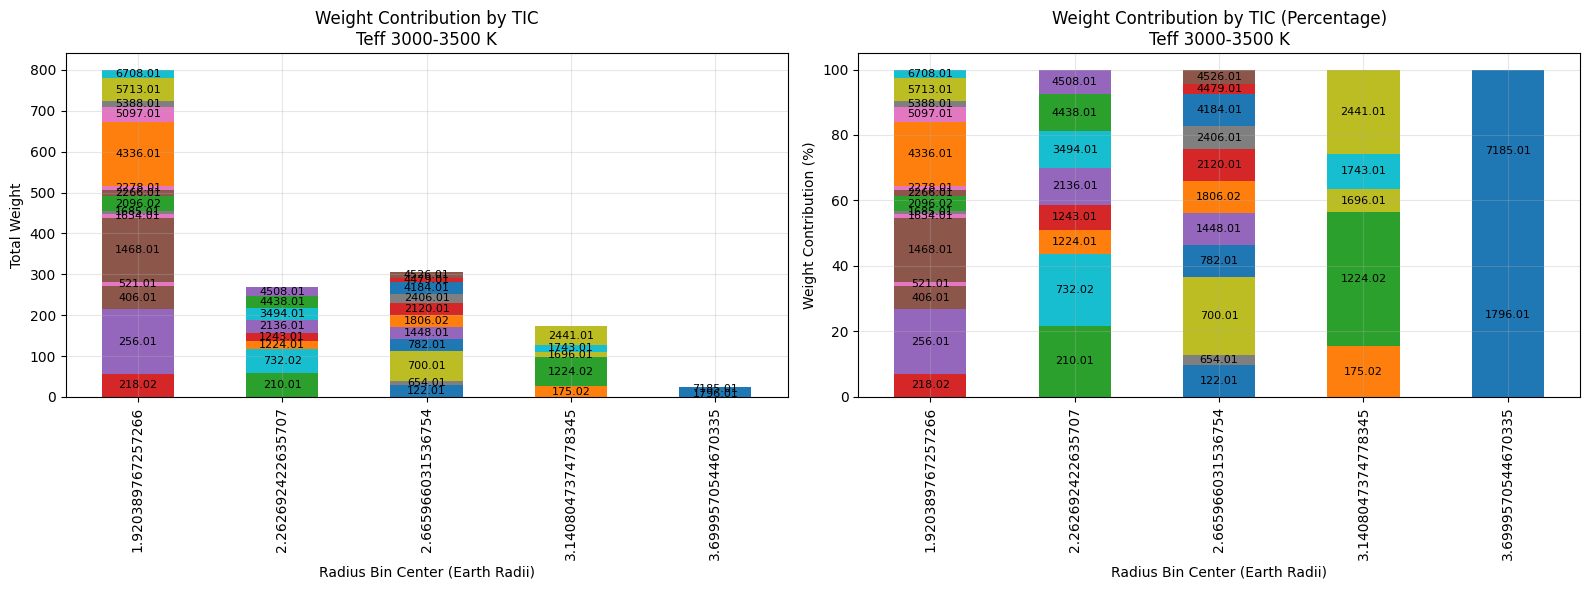


=== Teff 3000-3500 K ===
Total unique TICs: 41
Average weight per radius bin: 314.18

Top 5 TICs by total weight contribution:
  TIC 4336.01: 157.60 (10.0%)
  TIC 1468.01: 157.60 (10.0%)
  TIC 256.01: 157.60 (10.0%)
  TIC 700.01: 72.48 (4.6%)
  TIC 1224.02: 70.57 (4.5%)
toi                  177.01     233.01     269.01     270.01    270.02   \
radius_bin_center                                                         
1.920390           20.578572  60.043798   0.000000   0.000000   0.00000   
2.262692            0.000000   0.000000   0.000000  31.038509  47.31535   
2.665966            0.000000   0.000000   0.000000   0.000000   0.00000   
3.140805            0.000000   0.000000  16.848743   0.000000   0.00000   
3.699957            0.000000   0.000000   0.000000   0.000000   0.00000   

toi                  557.01     620.01     663.01     663.02     663.03   ...  \
radius_bin_center                                                         ...   
1.920390            0.000000   0.000000 

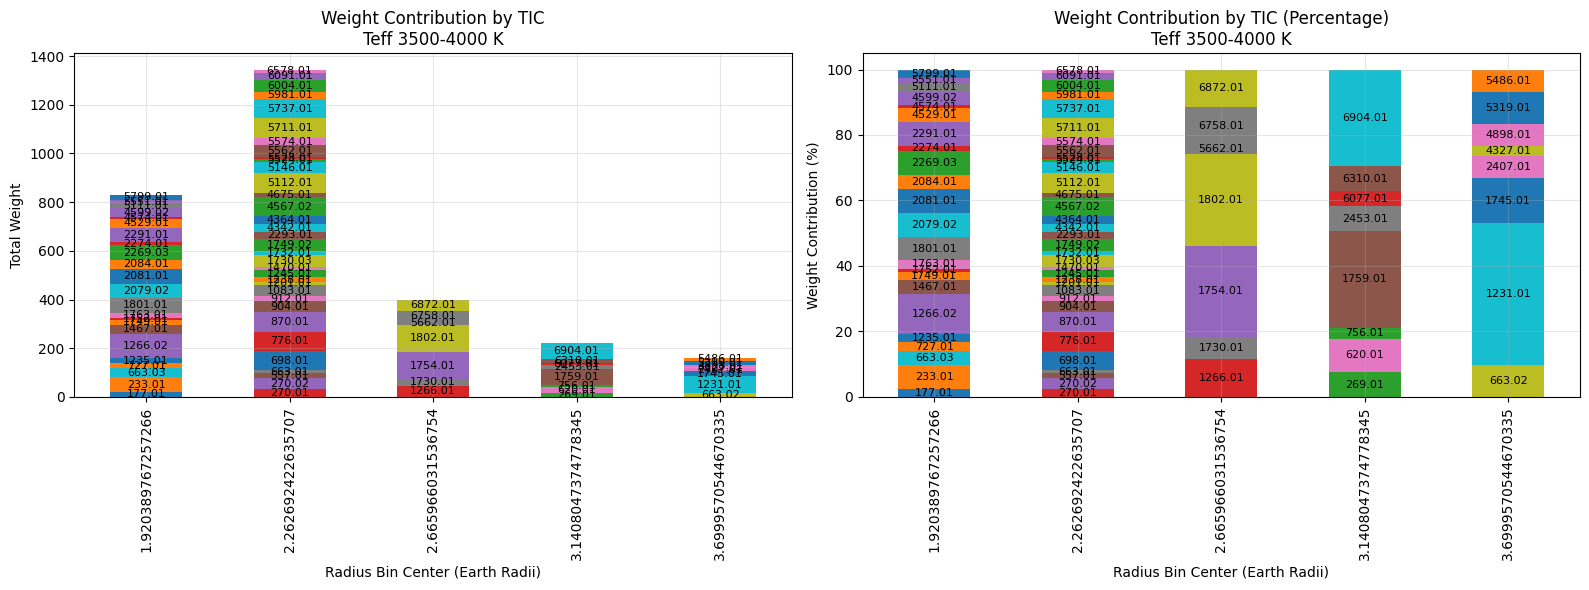


=== Teff 3500-4000 K ===
Total unique TICs: 80
Average weight per radius bin: 591.42

Top 5 TICs by total weight contribution:
  TIC 1754.01: 111.73 (3.8%)
  TIC 1802.01: 111.73 (3.8%)
  TIC 1266.02: 101.25 (3.4%)
  TIC 776.01: 79.34 (2.7%)
  TIC 5737.01: 79.34 (2.7%)
toi                  133.01     178.01     178.02     178.03     249.01   \
radius_bin_center                                                          
1.920390           26.428673   0.000000   0.000000   0.000000   0.000000   
2.262692            0.000000   0.000000   0.000000  45.213435  23.888972   
2.665966            0.000000  21.631549   0.000000   0.000000   0.000000   
3.140805            0.000000   0.000000   0.000000   0.000000   0.000000   
3.699957            0.000000   0.000000  45.807096   0.000000   0.000000   

toi                  260.01     279.01     475.01     702.01     711.01   ...  \
radius_bin_center                                                         ...   
1.920390           50.958673  50.95

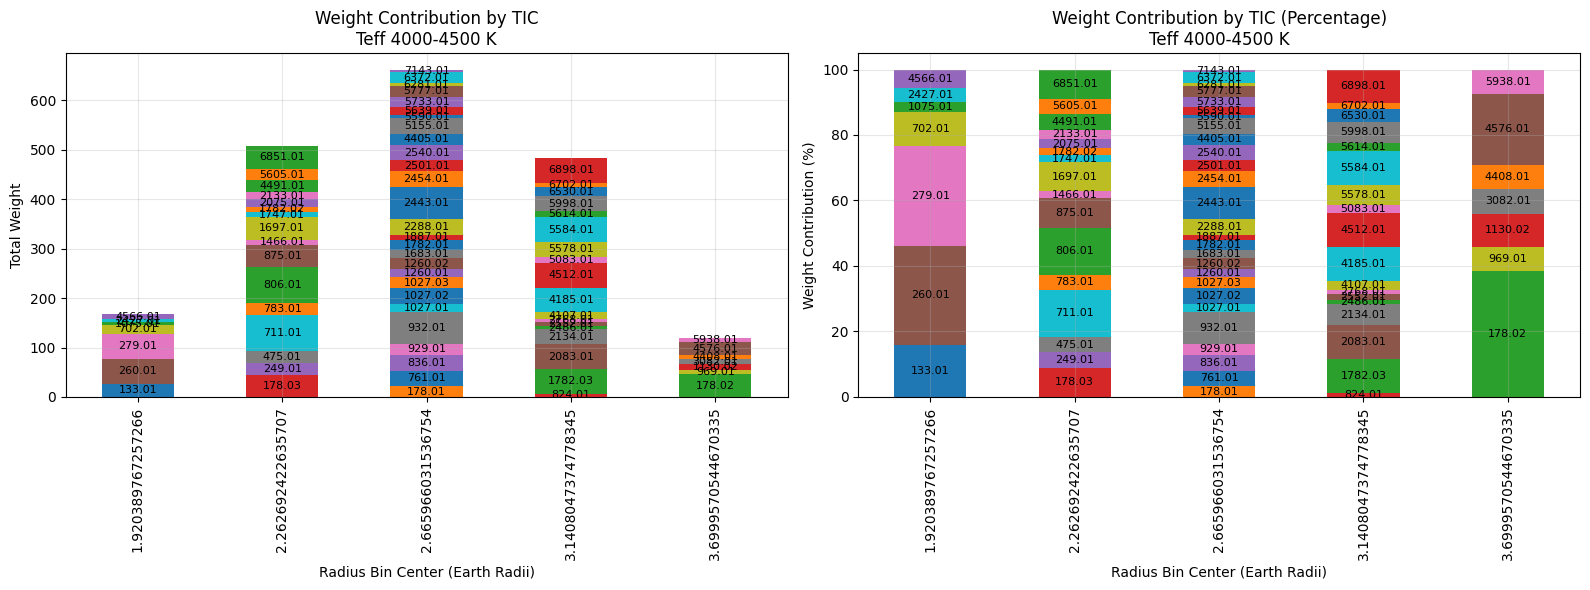


=== Teff 4000-4500 K ===
Total unique TICs: 75
Average weight per radius bin: 388.08

Top 5 TICs by total weight contribution:
  TIC 806.01: 72.74 (3.7%)
  TIC 711.01: 72.74 (3.7%)
  TIC 932.01: 65.78 (3.4%)
  TIC 2443.01: 65.78 (3.4%)
  TIC 279.01: 50.96 (2.6%)
toi                  174.01     213.01     431.01     461.01    494.01   \
radius_bin_center                                                         
1.920390           97.051569   0.000000   0.000000  53.552812  9.633033   
2.262692            0.000000  69.025755   0.000000   0.000000  0.000000   
2.665966            0.000000   0.000000   0.000000   0.000000  0.000000   
3.140805            0.000000   0.000000  30.373719   0.000000  0.000000   
3.699957            0.000000   0.000000   0.000000   0.000000  0.000000   

toi                  533.01    544.01     560.01     560.02     712.01   ...  \
radius_bin_center                                                        ...   
1.920390            0.000000  0.000000   0.000000 

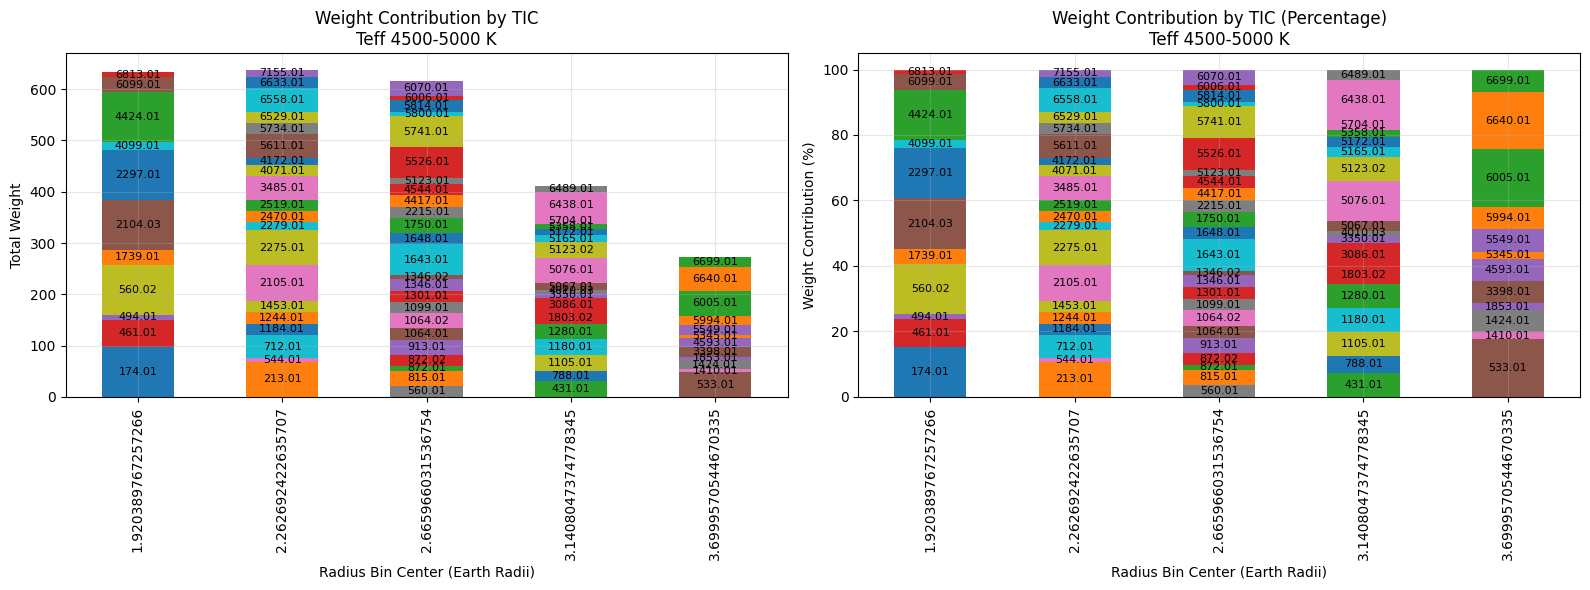


=== Teff 4500-5000 K ===
Total unique TICs: 85
Average weight per radius bin: 514.43

Top 5 TICs by total weight contribution:
  TIC 174.01: 97.05 (3.8%)
  TIC 560.02: 97.05 (3.8%)
  TIC 2104.03: 97.05 (3.8%)
  TIC 4424.01: 97.05 (3.8%)
  TIC 2297.01: 97.05 (3.8%)
toi                  119.01     125.01    125.02     125.03     179.01   \
radius_bin_center                                                         
1.920390           27.173778   0.000000   0.00000   0.000000   0.000000   
2.262692            0.000000   0.000000   0.00000   0.000000   0.000000   
2.665966            0.000000  12.440311  32.57523  52.772139  12.440311   
3.140805            0.000000   0.000000   0.00000   0.000000   0.000000   
3.699957            0.000000   0.000000   0.00000   0.000000   0.000000   

toi                  208.01    220.01     262.01     280.01      283.01   ...  \
radius_bin_center                                                         ...   
1.920390            0.000000   0.00000  56.501

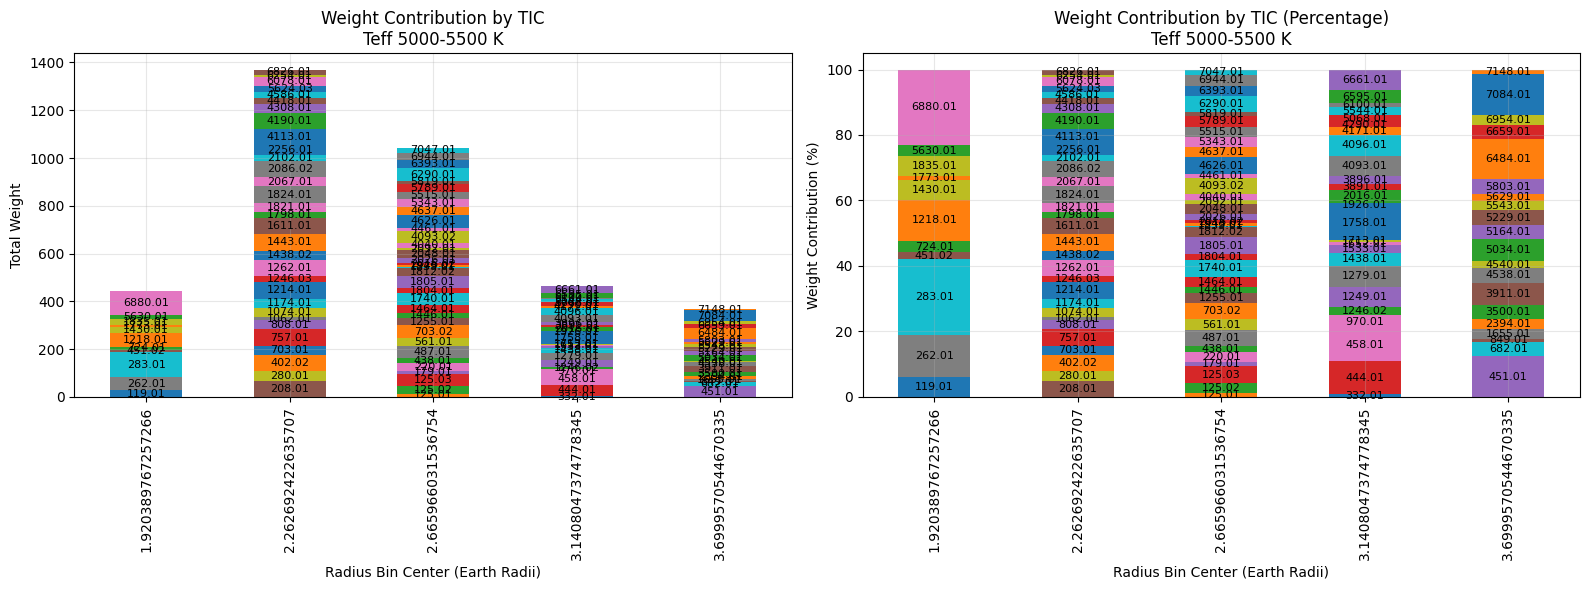


=== Teff 5000-5500 K ===
Total unique TICs: 122
Average weight per radius bin: 737.35

Top 5 TICs by total weight contribution:
  TIC 283.01: 102.93 (2.8%)
  TIC 6880.01: 102.93 (2.8%)
  TIC 4113.01: 68.94 (1.9%)
  TIC 757.01: 68.94 (1.9%)
  TIC 1214.01: 68.94 (1.9%)
toi                132.01     144.01     248.01     266.01     421.02   \
radius_bin_center                                                        
1.920390            0.0000  29.165972   0.000000   0.000000  29.165972   
2.262692            0.0000   0.000000  24.289417  42.365405   0.000000   
2.665966            0.0000   0.000000   0.000000   0.000000   0.000000   
3.140805            0.0000   0.000000   0.000000   0.000000   0.000000   
3.699957            7.1181   0.000000   0.000000   0.000000   0.000000   

toi                 426.01     509.01     509.02     518.01     652.01   ...  \
radius_bin_center                                                        ...   
1.920390           0.000000   0.000000   0.000000   

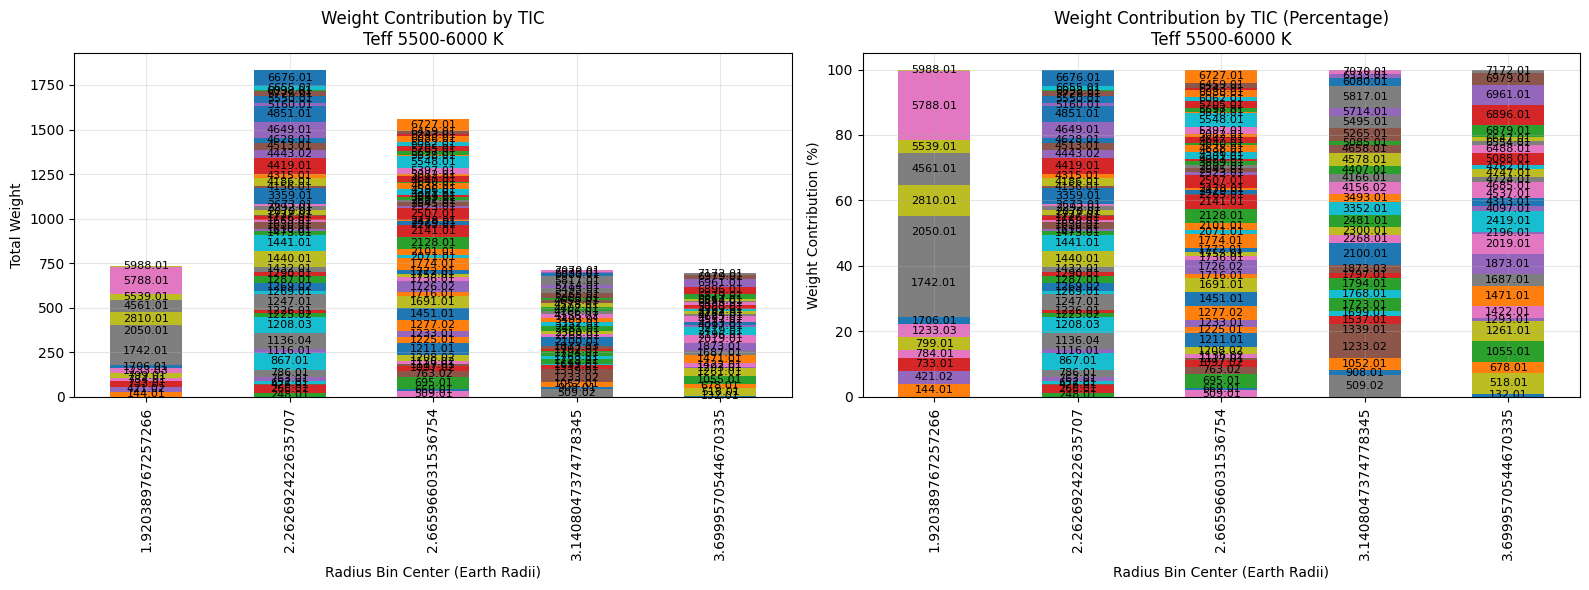


=== Teff 5500-6000 K ===
Total unique TICs: 168
Average weight per radius bin: 1107.05

Top 5 TICs by total weight contribution:
  TIC 5788.01: 154.22 (2.8%)
  TIC 1742.01: 154.22 (2.8%)
  TIC 4649.01: 90.34 (1.6%)
  TIC 6676.01: 90.34 (1.6%)
  TIC 1440.01: 90.34 (1.6%)
toi                  128.01     130.01    205.01     282.04     396.01   \
radius_bin_center                                                         
1.920390            0.000000   0.000000   0.00000   0.000000   0.000000   
2.262692           24.171302  44.095547  14.70905   0.000000  24.171302   
2.665966            0.000000   0.000000   0.00000  70.401503   0.000000   
3.140805            0.000000   0.000000   0.00000   0.000000   0.000000   
3.699957            0.000000   0.000000   0.00000   0.000000   0.000000   

toi                   396.03     411.01     469.01     480.01     554.01   \
radius_bin_center                                                           
1.920390           100.642233   0.000000   0.000

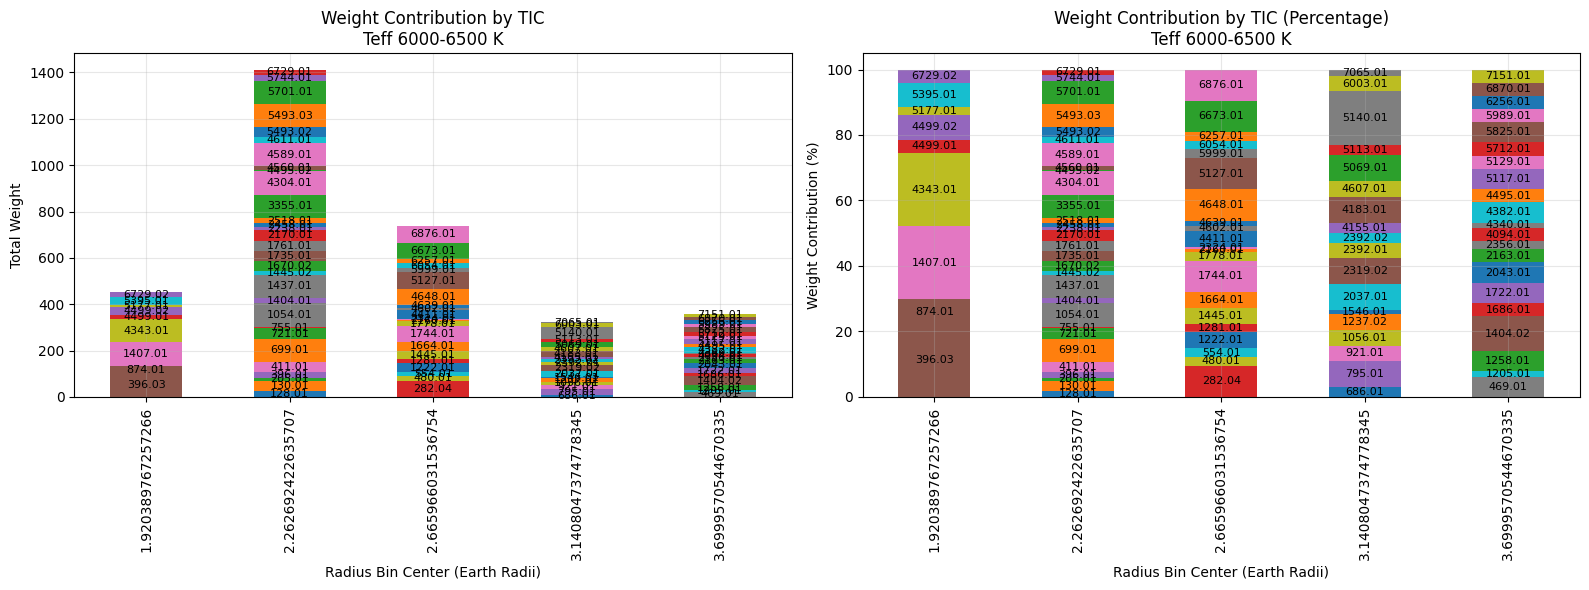


=== Teff 6000-6500 K ===
Total unique TICs: 99
Average weight per radius bin: 656.52

Top 5 TICs by total weight contribution:
  TIC 396.03: 100.64 (3.1%)
  TIC 1407.01: 100.64 (3.1%)
  TIC 4343.01: 100.64 (3.1%)
  TIC 1054.01: 100.22 (3.1%)
  TIC 5701.01: 100.22 (3.1%)
toi                 1204.01    1219.01   1620.01     1737.01    2166.01  \
radius_bin_center                                                         
1.920390           6.488488  12.437169  0.000000    0.000000   0.000000   
2.262692           0.000000   0.000000  8.733655    0.000000   0.000000   
2.665966           0.000000   0.000000  0.000000  161.888911   0.000000   
3.140805           0.000000   0.000000  0.000000    0.000000  16.542168   
3.699957           0.000000   0.000000  0.000000    0.000000   0.000000   

toi                2465.01    4299.01    4362.01    4369.01   5118.01  \
radius_bin_center                                                       
1.920390            0.0000   0.000000   0.000000   0.000

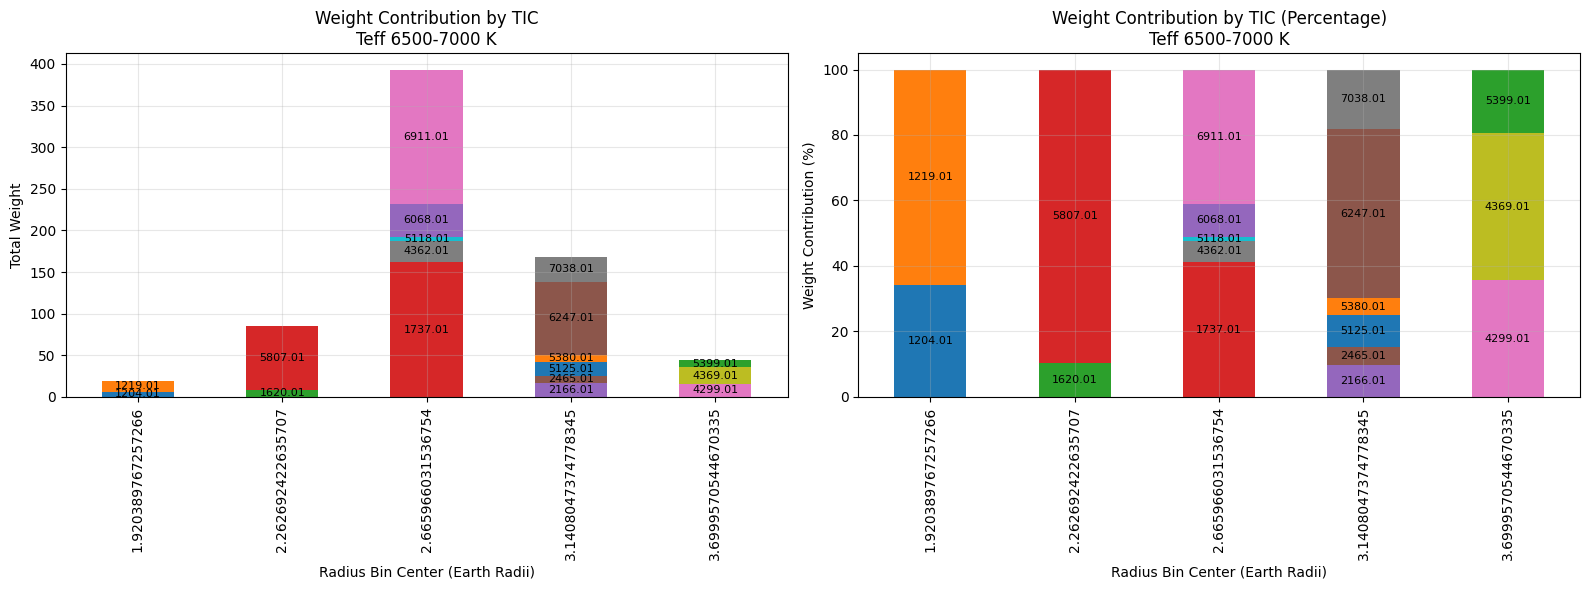


=== Teff 6500-7000 K ===
Total unique TICs: 18
Average weight per radius bin: 141.94

Top 5 TICs by total weight contribution:
  TIC 6911.01: 161.89 (22.8%)
  TIC 1737.01: 161.89 (22.8%)
  TIC 6247.01: 86.80 (12.2%)
  TIC 5807.01: 75.95 (10.7%)
  TIC 6068.01: 38.71 (5.5%)


In [59]:
#for each radius, I want to know the weight contribution of each tic in a stacked histogram, with percentages

# For each radius bin, show weight contribution of each TIC in a stacked histogram with percentages
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])].copy()
    
    if len(teff_df) == 0:
        continue
    
    # Add radius bin center for grouping
    # Calculate radius bin center in log space
    teff_df['radius_bin_center'] = 10 ** ((np.log10(teff_df['radius_bin_min']) + np.log10(teff_df['radius_bin_max'])) / 2)
    #how does it get the right bins from just the center
    # Create pivot table: rows=radius bins, columns=TICs, values=sum of weights
    pivot = teff_df.pivot_table(
        index='radius_bin_center',
        columns='toi',
        values='weight',
        aggfunc='sum',
        fill_value=0
    )
    print(pivot)
    # Calculate percentage contribution per radius bin
    pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Absolute weights
    bars1 = pivot.plot(kind='bar', stacked=True, ax=ax1, legend=False)
    ax1.set_xlabel('Radius Bin Center (Earth Radii)')
    ax1.set_ylabel('Total Weight')
    ax1.set_title(f'Weight Contribution by TIC\nTeff {temp_range[0]}-{temp_range[1]} K')
    ax1.grid(True, alpha=0.3)
    
    # Add TIC labels on bars for plot 1
    for i, radius_bin in enumerate(pivot.index):
        cumulative = 0
        for j, toi in enumerate(pivot.columns):
            height = pivot.loc[radius_bin, toi]
            if height > 0:  # Only label if there's a contribution
                ax1.text(i, cumulative + height/2, f'{toi:.2f}', 
                        ha='center', va='center', fontsize=8, rotation=0)
                cumulative += height
    
    # Plot 2: Percentage weights
    bars2 = pivot_percent.plot(kind='bar', stacked=True, ax=ax2, legend=False)
    ax2.set_xlabel('Radius Bin Center (Earth Radii)')
    ax2.set_ylabel('Weight Contribution (%)')
    ax2.set_title(f'Weight Contribution by TIC (Percentage)\nTeff {temp_range[0]}-{temp_range[1]} K')
    ax2.grid(True, alpha=0.3)
    
    # Add TIC labels on bars for plot 2
    for i, radius_bin in enumerate(pivot_percent.index):
        cumulative = 0
        for j, toi in enumerate(pivot_percent.columns):
            height = pivot_percent.loc[radius_bin, toi]
            if height > 0:  # Only label if there's a contribution
                ax2.text(i, cumulative + height/2, f'{toi:.2f}', 
                        ha='center', va='center', fontsize=8, rotation=0)
                cumulative += height
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== Teff {temp_range[0]}-{temp_range[1]} K ===")
    print(f"Total unique TICs: {len(pivot.columns)}")
    print(f"Average weight per radius bin: {pivot.sum(axis=1).mean():.2f}")
    print("\nTop 5 TICs by total weight contribution:")
    top_tics = pivot.sum(axis=0).sort_values(ascending=False).head(5)
    for tic, weight in top_tics.items():
        print(f"  TIC {tic}: {weight:.2f} ({weight/pivot.sum().sum()*100:.1f}%)")

688 TOIs for bootstrapping


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


   Teff Range  Weighted Median Radius (Earth Radii)  \
0  3000-3500K                              2.060810   
1  3500-4000K                              2.249375   
2  4000-4500K                              2.686889   
3  4500-5000K                              2.460344   
4  5000-5500K                              2.461646   
5  5500-6000K                              2.519480   
6  6000-6500K                              2.443170   
7  6500-7000K                              2.797790   

   Weighted Median Error (Earth Radii)  
0                             0.103035  
1                             0.038630  
2                             0.070373  
3                             0.095133  
4                             0.042242  
5                             0.056015  
6                             0.029219  
7                             0.055095  


(-0.0, 0.07)

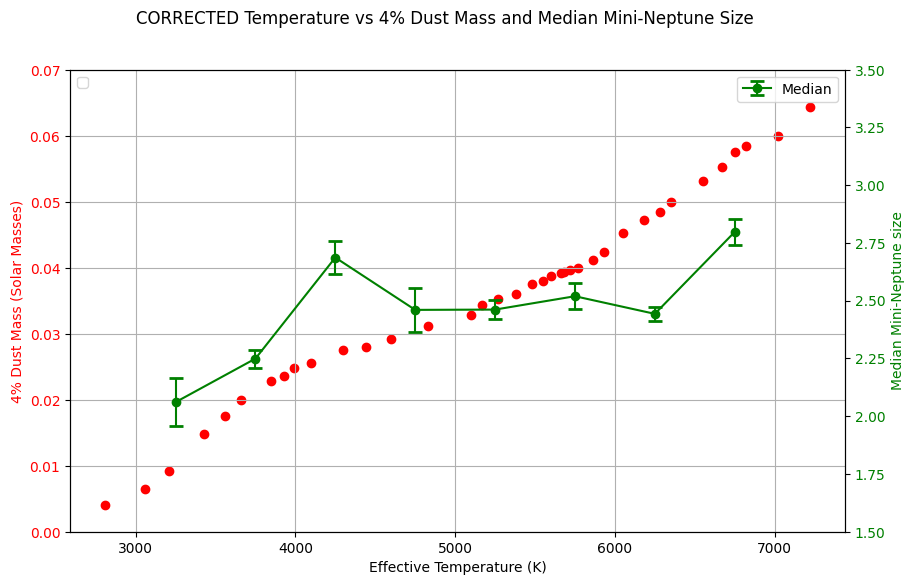

In [60]:
n_bootstrap = 1000
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

# Calculate bootstrapping errors for weighted medians
def calculate_weighted_median(vals, weights):
    """Calculate weighted median"""
    if len(vals) == 0 or weights.sum() == 0:
        return np.nan
    sorted_idx = np.argsort(vals)
    vals_sorted = vals[sorted_idx]
    weights_sorted = weights[sorted_idx]
    cumsum = np.cumsum(weights_sorted)
    cutoff = weights_sorted.sum() / 2.0
    return vals_sorted[np.searchsorted(cumsum, cutoff)]

# Load TOI data for bootstrapping
TOIs_bootstrap = TOIs_filtered
TOIs_bootstrap = TOIs_bootstrap.dropna(subset=['st_teff', 'pl_rade'])
TOIs_bootstrap = TOIs_bootstrap[(TOIs_bootstrap['pl_rade'] > 1.5) & (TOIs_bootstrap['pl_rade'] < 4.0)]
TOIs_bootstrap = TOIs_bootstrap[(TOIs_bootstrap['pl_orbper'] > 0.519) & (TOIs_bootstrap['pl_orbper'] <30)]
#TOIs_bootstrap = TOIs_bootstrap[TOIs_bootstrap['tfopwg_disp'] == 'FP']


print(len(TOIs_bootstrap), "TOIs for bootstrapping")
if 'tfopwg_disp' in TOIs_bootstrap.columns:
    TOIs_bootstrap = TOIs_bootstrap[TOIs_bootstrap['tfopwg_disp'] != 'FP']

# Calculate weighted median errors using bootstrapping
#print(teff_ranges)
weighted_median_errors = []
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    
    # Get original data for this temperature bin
    bin_mask = (TOIs_bootstrap['st_teff'] >= temp_range[0]) & (TOIs_bootstrap['st_teff'] < temp_range[1])
    toi_indices = TOIs_bootstrap.loc[bin_mask].index
    n_tois = len(toi_indices)
    
    if n_tois == 0:
        weighted_median_errors.append(np.nan)
        continue
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        # Resample TOI indices with replacement
        bootstrap_indices = np.random.choice(toi_indices, size=n_tois, replace=True)
        
        # Get corresponding rows from merged_df for these TOIs
        bootstrap_teff_df = merged_df[merged_df['toi'].isin(TOIs_bootstrap.loc[bootstrap_indices, 'toi'])]
        bootstrap_teff_df = bootstrap_teff_df[(bootstrap_teff_df['st_teff'] >= temp_range[0]) & 
                                               (bootstrap_teff_df['st_teff'] < temp_range[1])]
         
        if len(bootstrap_teff_df) > 0:
            vals = bootstrap_teff_df['pl_rade'].values
            weights = bootstrap_teff_df['weight'].values
            bootstrap_median = calculate_weighted_median(vals, weights)
            bootstrap_medians.append(bootstrap_median)
    
    median_error = np.std(bootstrap_medians)
    weighted_median_errors.append(median_error)
    #print(weighted_median_errors)
    #print(f"Teff {temp_range[0]}-{temp_range[1]} K: N={n_tois}, Error={median_error:.3f} R_Earth")

# Add errors to radius_medians dataframe
radius_medians['Weighted Median Error (Earth Radii)'] = weighted_median_errors
print(radius_medians)
#print(radius_medians)

fig, ax1 = plt.subplots(figsize=(10, 6))



median_df = radius_medians#
#print(median_df)

median_df['Teff Range Average'] = median_df['Teff Range'].apply(
    lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
)

corrected_mean_median_df = median_df
# corrected_mean_median_df['Teff Range Average'] = corrected_mean_median_df['Teff Range'].apply(
#     lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
# )

# Create a secondary y-axis for Median
ax2 = ax1.twinx()
ax2.errorbar(corrected_mean_median_df['Teff Range Average'], 
             corrected_mean_median_df['Weighted Median Radius (Earth Radii)'], 
             yerr=corrected_mean_median_df['Weighted Median Error (Earth Radii)'],
             color='g', label='Median', marker='o', linestyle='-', capsize=5, capthick=2)
ax2.set_ylabel('Median Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(1.5,3.50)

# Add a title and legend
fig.suptitle('CORRECTED Temperature vs 4% Dust Mass and Median Mini-Neptune Size')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')





data = {
    'Stellar Type': ['M0V', 'M1V', 'M2V', 'M3V', 'M4V', 'M5V', 'M6V', 'K0V', 'K1V', 'K2V', 'K3V', 'K4V', 'K5V', 'K6V', 'K7V', 'K8V', 'K9V',
                     'G0V', 'G1V', 'G2V', 'G3V', 'G4V', 'G5V', 'G6V', 'G7V', 'G8V', 'G9V',
                     'F0V', 'F1V', 'F2V', 'F3V', 'F4V', 'F5V', 'F6V', 'F7V', 'F8V', 'F9V'],
    'Mass': [0.57, 0.50, 0.44, 0.37, 0.23, 0.162, 0.102, 0.88, 0.86, 0.82, 0.78, 0.73, 0.70, 0.69, 0.64, 0.62, 0.59,
             1.06, 1.03, 1.00, 0.99, 0.985, 0.98, 0.97, 0.95, 0.94, 0.90,
             1.61, 1.50, 1.46, 1.44, 1.38, 1.33, 1.25, 1.21, 1.18, 1.13],
    'Radius': [0.588, 0.501, 0.446, 0.361, 0.274, 0.196, 0.137, 0.813, 0.797, 0.783, 0.755, 0.713, 0.701, 0.669, 0.630, 0.615, 0.608,
               1.100, 1.060, 1.012, 1.002, 0.991, 0.977, 0.949, 0.927, 0.914, 0.853,
               1.728, 1.679, 1.622, 1.578, 1.533, 1.473, 1.359, 1.324, 1.221, 1.167],
    'Luminosity': [0.069, 0.041, 0.029, 0.016, 7.2e-3, 3.0e-3, 1.0e-3, 0.46, 0.41, 0.37, 0.28, 0.20, 0.17, 0.14, 0.10, 0.087, 0.079,
                   1.35, 1.20, 1.02, 0.98, 0.91, 0.89, 0.79, 0.74, 0.68, 0.55,
                   7.24, 6.17, 5.13, 4.68, 4.17, 3.63, 2.69, 2.45, 1.95, 1.66],
    'Effective Temperature': [3850, 3660, 3560, 3430, 3210, 3060, 2810, 5270, 5170, 5100, 4830, 4600, 4440, 4300, 4100, 3990, 3930,
                              5930, 5860, 5770, 5720, 5680, 5660, 5600, 5550, 5480, 5380,
                              7220, 7020, 6820, 6750, 6670, 6550, 6350, 6280, 6180, 6050],
    'B-V Index': [1.42, 1.49, 1.51, 1.53, 1.65, 1.83, 2.01, 0.82, 0.86, 0.88, 0.99, 1.09, 1.15, 1.24, 1.34, 1.36, 1.40,
                  0.60, 0.62, 0.65, 0.66, 0.67, 0.68, 0.70, 0.71, 0.73, 0.78,
                  0.30, 0.33, 0.37, 0.39, 0.41, 0.44, 0.49, 0.50, 0.53, 0.56]
}
data['4% Dust Mass'] = [mass * 0.04 for mass in data['Mass']]
data['1/R^2'] = [1 / (radius ** 2) for radius in data['Radius']]

stellar_df = pd.DataFrame(data)
stellar_df = stellar_df.sort_values(by='Effective Temperature', ascending=True)



# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)
ax1.set_ylim(-.00,.07)
#ax1.set_ylim(-.01,.0)



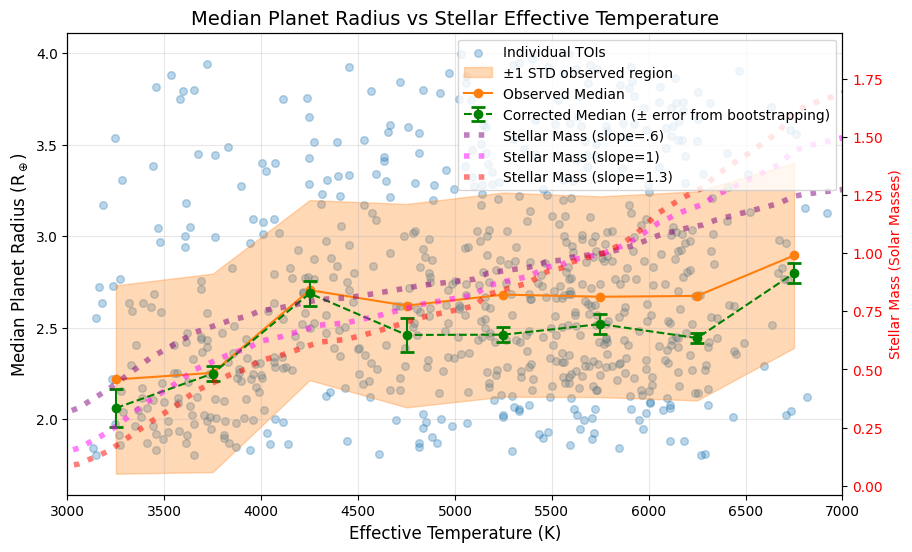

In [61]:
# Quick replot of the planet radius vs. stellar temperature with individual points
import matplotlib.pyplot as plt

bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]
pl_limits = [1.8, 4]

# Filter as before
TOIs_plot = TOIs[(TOIs['tfopwg_disp'] != 'FA') &
                (TOIs['pl_rade'] > pl_limits[0]) &
                (TOIs['pl_rade'] < pl_limits[1]) &
                (TOIs['pl_orbper'] < 25.1) &
                (TOIs['pl_orbper'] > 0.531) 
]


planet_radii_medians = []
bin_centers = []
stds = []

fig, ax = plt.subplots(figsize=(10, 6))

stellar_data = {
    'Effective Temperature': [3850, 3660, 3560, 3430, 3210, 3060, 2810, 5270, 5170, 5100, 4830, 4600, 4440, 4300, 4100, 3990, 3930,
                              5930, 5860, 5770, 5720, 5680, 5660, 5600, 5550, 5480, 5380,
                              7220, 7020, 6820, 6750, 6670, 6550, 6350, 6280, 6180, 6050],
    'Mass': [0.57, 0.50, 0.44, 0.37, 0.23, 0.162, 0.102, 0.88, 0.86, 0.82, 0.78, 0.73, 0.70, 0.69, 0.64, 0.62, 0.59,
             1.06, 1.03, 1.00, 0.99, 0.985, 0.98, 0.97, 0.95, 0.94, 0.90,
             1.61, 1.50, 1.46, 1.44, 1.38, 1.33, 1.25, 1.21, 1.18, 1.13]
}
stellar_df = pd.DataFrame(stellar_data)
stellar_df = stellar_df.sort_values(by='Effective Temperature', ascending=True)
stellar_df['4% Dust Mass'] = stellar_df['Mass'] * 0.04

ax.set_xlim(3000, 7000)

# Now plot ax2 below everything else
ax2 = ax.twinx()
# Add stellar mass line with slope 1.3
scaled_mass_2 = stellar_df['Mass'] ** 0.6
ax2.plot(stellar_df['Effective Temperature'], scaled_mass_2, color='purple', linestyle=':', label='Stellar Mass (slope=.6)', alpha=0.5, linewidth=4)


ax2.plot(stellar_df['Effective Temperature'], stellar_df['Mass'], color='magenta', linestyle=':', label='Stellar Mass (slope=1)', alpha=0.5, linewidth=4)

# Add stellar mass line with slope 1.3
scaled_mass = stellar_df['Mass'] ** 1.3
ax2.plot(stellar_df['Effective Temperature'], scaled_mass, color='r', linestyle=':', label='Stellar Mass (slope=1.3)', alpha=0.5, linewidth=4)


ax2.set_ylabel('Stellar Mass (Solar Masses)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs_plot['st_teff'] >= bins_teff[i]) & (TOIs_plot['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs_plot.loc[bin_mask, 'pl_rade']
    planet_teff = TOIs_plot.loc[bin_mask, 'st_teff']
    planet_radii_n = len(planet_radii)
    if planet_radii_n > 0:
        std = np.std(planet_radii)
        median = np.median(planet_radii)
        stds.append(std)
        planet_radii_medians.append(median)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        # Plot individual points at true temperature
        ax.scatter(planet_teff, planet_radii, color='C0', alpha=0.3, s=30, label='Individual TOIs' if i == 0 else "")
    else:
        stds.append(np.nan)
        planet_radii_medians.append(np.nan)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

# Draw shaded region like symmetric std error bars
bin_centers_arr = np.array(bin_centers)
medians_arr = np.array(planet_radii_medians)
stds_arr = np.array(stds)
ax.fill_between(bin_centers_arr, medians_arr-stds_arr, medians_arr+stds_arr, color='C1', alpha=0.3, label='±1 STD observed region')
ax.plot(bin_centers_arr, medians_arr, marker='o', color='C1', label='Observed Median')

# Add corrected median planet radius from the cell above (radius_medians DataFrame) with error bars from bootstrapping
if 'radius_medians' in globals():
    # Use the Teff Range Average and Weighted Median Radius columns
    if 'Teff Range Average' not in radius_medians.columns:
        radius_medians['Teff Range Average'] = radius_medians['Teff Range'].apply(
            lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
        )
    # Plot corrected median with error bars from bootstrapping
    ax.errorbar(radius_medians['Teff Range Average'],
                radius_medians['Weighted Median Radius (Earth Radii)'],
                yerr=radius_medians['Weighted Median Error (Earth Radii)'],
                marker='o', color='g', linestyle='--', label='Corrected Median (± error from bootstrapping)', capsize=5, capthick=2)

# Add 4% dust mass on a secondary y-axis
# Stellar data for 4% dust mass

# Add legend for both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

ax.set_xlabel('Effective Temperature (K)', fontsize=12)
ax.set_ylabel('Median Planet Radius (R$_\oplus$)', fontsize=12)
ax.set_title('Median Planet Radius vs Stellar Effective Temperature', fontsize=14)
ax.grid(True, alpha=0.3)
plt.show()


Teff 3000-3500 K: N=41, Median=2.22, Error=0.174 R_Earth
Teff 3500-4000 K: N=80, Median=2.25, Error=0.044 R_Earth
Teff 4000-4500 K: N=75, Median=2.71, Error=0.076 R_Earth
Teff 4500-5000 K: N=85, Median=2.62, Error=0.082 R_Earth
Teff 5000-5500 K: N=122, Median=2.68, Error=0.057 R_Earth
Teff 5500-6000 K: N=168, Median=2.67, Error=0.056 R_Earth
Teff 6000-6500 K: N=99, Median=2.67, Error=0.096 R_Earth
Teff 6500-7000 K: N=18, Median=2.89, Error=0.138 R_Earth

Total bins: 8, 8, 8


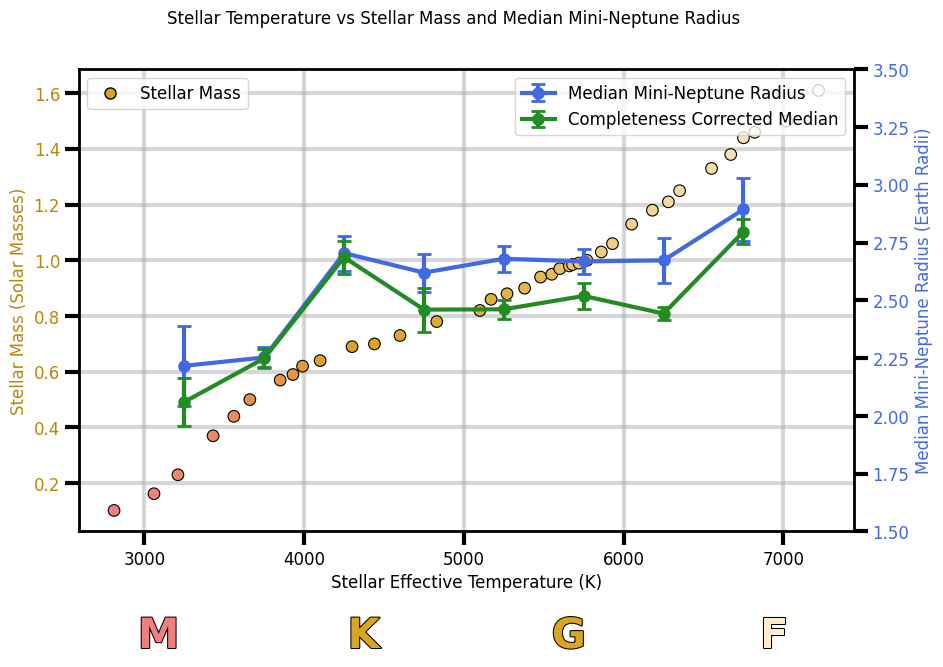

In [62]:
#### PRESENTATION VERSION ####

# Bootstrap error calculation
n_bootstrap = 1000

# Load TOI data for bootstrapping
TOIs = pd.read_csv('../TOI_Mar2025_1pt5to4_R_detected_real_only.csv')
TOIs = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs = TOIs[(TOIs['pl_rade'] > 1.8) & (TOIs['pl_rade'] < 4.0)]
TOIs = TOIs[(TOIs['pl_orbper'] > 0.531) & (TOIs['pl_orbper'] < 25.1)]
if 'tfopwg_disp' in TOIs.columns:
    TOIs = TOIs[TOIs['tfopwg_disp'] != 'FP']

# Define temperature bins matching mean_median_df
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

planet_radii_medians = []
planet_radii_errors = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    
    if planet_radii_n == 0:
        planet_radii_errors.append(np.nan)
        planet_radii_medians.append(np.nan)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        continue
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_radii.sample(n=planet_radii_n, replace=True)
        bootstrap_medians.append(np.median(bootstrap_sample))
    
    planet_radii_error = np.std(bootstrap_medians)
    planet_radii_median = np.median(planet_radii)
    
    print(f"Teff {bins_teff[i]}-{bins_teff[i+1]} K: N={planet_radii_n}, Median={planet_radii_median:.2f}, Error={planet_radii_error:.3f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(f"\nTotal bins: {len(planet_radii_medians)}, {len(planet_radii_errors)}, {len(bin_centers)}")

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

import matplotlib.colors as mcolors

# Gradual color transition for scatter points
n_points = len(stellar_df)
colors = []
for i in range(n_points):
    ratio = i / (n_points - 1)
    if ratio <= 0.3:
        local_ratio = ratio / 0.3
        r = 240 + (218 - 240) * local_ratio
        g = 128 + (165 - 128) * local_ratio
        b = 128 + (32 - 128) * local_ratio
    else:
        local_ratio = (ratio - 0.3) / 0.7
        r = 218 + (255 - 218) * local_ratio
        g = 165 + (235 - 165) * local_ratio
        b = 32 + (205 - 32) * local_ratio
    colors.append((r/255, g/255, b/255))

from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke
ax1.grid(True, linewidth =3, alpha=.5, zorder=0)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Stellar Mass',
                          markerfacecolor='goldenrod', markeredgecolor='black', markersize=8, linewidth=.1)]
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], 
           c=colors, edgecolor='black', linewidth=0.8, s=70, zorder = 3)
ax1.set_xlabel('Stellar Effective Temperature (K)', size=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', color='darkgoldenrod', size=12)
ax1.tick_params(axis='y', labelcolor='darkgoldenrod')
#ax1.set_ylim(-.00,.07)

# Add colored spectral type labels to the bottom of the plot with black outline
outline = [withStroke(linewidth=1.5, foreground='black')]
xmin, xmax = ax1.get_xlim()
y_bottom = ax1.get_ylim()[0] - .3
x_positions = np.linspace(xmin + 500, xmax - 500, 4)
ax1.text(x_positions[0], y_bottom, 'M', color='lightcoral', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[1], y_bottom, 'K', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[2], y_bottom, 'G', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[3], y_bottom, 'F', color='blanchedalmond', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# Secondary y-axis for Median with error bars
ax2 = ax1.twinx()
ax2.errorbar(
    bin_centers, planet_radii_medians, yerr=planet_radii_errors,
    color='royalblue', label='Median Mini-Neptune Radius', marker='o', 
    linestyle='-', markersize=8, linewidth=3, capsize=5, capthick=2
)
ax2.set_ylabel('Median Mini-Neptune Radius (Earth Radii)', color='royalblue', size=12)
ax2.tick_params(axis='y', labelcolor='royalblue', size=12)
ax2.set_ylim(1.5, 3.5)

# Add completeness-corrected medians (green) in the same style
if 'corrected_mean_median_df' in globals():
    ax2.errorbar(
        corrected_mean_median_df['Teff Range Average'],
        corrected_mean_median_df['Weighted Median Radius (Earth Radii)'],
        yerr=corrected_mean_median_df['Weighted Median Error (Earth Radii)'],
        color='forestgreen', label='Completeness Corrected Median',
        marker='o', linestyle='-', markersize=8, linewidth=3,
        capsize=5, capthick=2
    )


fig.suptitle('Stellar Temperature vs Stellar Mass and Median Mini-Neptune Radius', size=12)
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax1.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax1.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
ax2.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax2.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
for spine in ax1.spines.values():
    spine.set_linewidth(2)
plt.show()

fig.savefig('stellar_temp_vs_disk_mass_and_median_radius.png', dpi=300, bbox_inches='tight')


Teff 3000-3500 K: N=54, Median=2.06, Error=0.082 R_Earth
Teff 3500-4000 K: N=94, Median=2.21, Error=0.060 R_Earth
Teff 4000-4500 K: N=82, Median=2.64, Error=0.086 R_Earth
Teff 4500-5000 K: N=97, Median=2.56, Error=0.092 R_Earth
Teff 5000-5500 K: N=133, Median=2.63, Error=0.063 R_Earth
Teff 5500-6000 K: N=189, Median=2.57, Error=0.058 R_Earth
Teff 6000-6500 K: N=105, Median=2.60, Error=0.093 R_Earth
Teff 6500-7000 K: N=19, Median=2.83, Error=0.164 R_Earth

Total bins: 8, 8, 8

--- Linear Fit to Completeness Corrected Median ---
Slope: 1.3397e-04 R_Earth/K
Intercept: 1.7901 R_Earth
Equation: Radius = 1.3397e-04 * Teff + 1.7901


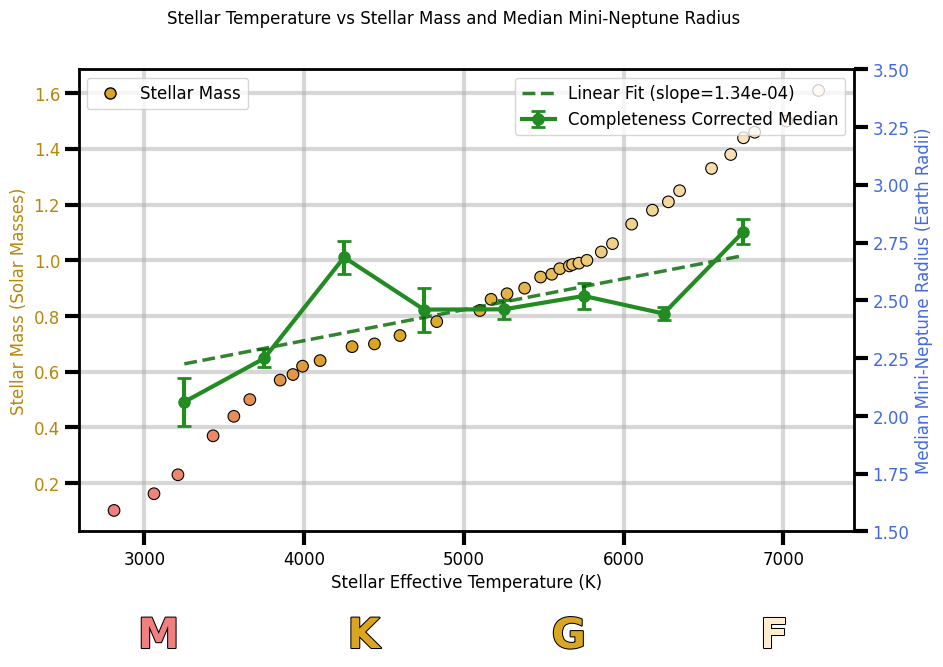

In [63]:
#### PRESENTATION VERSION ####

# Bootstrap error calculation
n_bootstrap = 1000

# Load TOI data for bootstrapping
TOIs = pd.read_csv('../TOI_Mar2025_1pt5to4_R_detected_real_only.csv')
TOIs = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs = TOIs[(TOIs['pl_rade'] > 1.5) & (TOIs['pl_rade'] < 4.0)]
TOIs = TOIs[(TOIs['pl_orbper'] > 0.519) & (TOIs['pl_orbper'] < 30)]
if 'tfopwg_disp' in TOIs.columns:
    TOIs = TOIs[TOIs['tfopwg_disp'] != 'FP']

# Define temperature bins matching mean_median_df
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

planet_radii_medians = []
planet_radii_errors = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    
    if planet_radii_n == 0:
        planet_radii_errors.append(np.nan)
        planet_radii_medians.append(np.nan)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        continue
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_radii.sample(n=planet_radii_n, replace=True)
        bootstrap_medians.append(np.median(bootstrap_sample))
    
    planet_radii_error = np.std(bootstrap_medians)
    planet_radii_median = np.median(planet_radii)
    
    print(f"Teff {bins_teff[i]}-{bins_teff[i+1]} K: N={planet_radii_n}, Median={planet_radii_median:.2f}, Error={planet_radii_error:.3f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(f"\nTotal bins: {len(planet_radii_medians)}, {len(planet_radii_errors)}, {len(bin_centers)}")

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

import matplotlib.colors as mcolors

# Gradual color transition for scatter points
n_points = len(stellar_df)
colors = []
for i in range(n_points):
    ratio = i / (n_points - 1)
    if ratio <= 0.3:
        local_ratio = ratio / 0.3
        r = 240 + (218 - 240) * local_ratio
        g = 128 + (165 - 128) * local_ratio
        b = 128 + (32 - 128) * local_ratio
    else:
        local_ratio = (ratio - 0.3) / 0.7
        r = 218 + (255 - 218) * local_ratio
        g = 165 + (235 - 165) * local_ratio
        b = 32 + (205 - 32) * local_ratio
    colors.append((r/255, g/255, b/255))

from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke
ax1.grid(True, linewidth =3, alpha=.5, zorder=0)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Stellar Mass',
                          markerfacecolor='goldenrod', markeredgecolor='black', markersize=8, linewidth=.1)]
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], 
           c=colors, edgecolor='black', linewidth=0.8, s=70, zorder = 3)
ax1.set_xlabel('Stellar Effective Temperature (K)', size=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', color='darkgoldenrod', size=12)
ax1.tick_params(axis='y', labelcolor='darkgoldenrod')
#ax1.set_ylim(-.00,.07)

# Add colored spectral type labels to the bottom of the plot with black outline
outline = [withStroke(linewidth=1.5, foreground='black')]
xmin, xmax = ax1.get_xlim()
y_bottom = ax1.get_ylim()[0] - .3
x_positions = np.linspace(xmin + 500, xmax - 500, 4)
ax1.text(x_positions[0], y_bottom, 'M', color='lightcoral', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[1], y_bottom, 'K', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[2], y_bottom, 'G', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[3], y_bottom, 'F', color='blanchedalmond', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# Secondary y-axis for Median with error bars
ax2 = ax1.twinx()
# ax2.errorbar(
#     bin_centers, planet_radii_medians, yerr=planet_radii_errors,
#     color='royalblue', label='Median Mini-Neptune Radius', marker='o', 
#     linestyle='-', markersize=8, linewidth=3, capsize=5, capthick=2
#)
ax2.set_ylabel('Median Mini-Neptune Radius (Earth Radii)', color='royalblue', size=12)
ax2.tick_params(axis='y', labelcolor='royalblue', size=12)
ax2.set_ylim(1.5, 3.5)

# Add completeness-corrected medians (green) in the same style
if 'corrected_mean_median_df' in globals():
    ax2.errorbar(
        corrected_mean_median_df['Teff Range Average'],
        corrected_mean_median_df['Weighted Median Radius (Earth Radii)'],
        yerr=corrected_mean_median_df['Weighted Median Error (Earth Radii)'],
        color='forestgreen', label='Completeness Corrected Median',
        marker='o', linestyle='-', markersize=8, linewidth=3,
        capsize=5, capthick=2
    )
    
    # Fit a straight line to the completeness corrected data
    # Remove NaN values for fitting
    x_fit = corrected_mean_median_df['Teff Range Average'].values
    y_fit = corrected_mean_median_df['Weighted Median Radius (Earth Radii)'].values
    
    # Filter out NaN values
    valid_mask = ~(np.isnan(x_fit) | np.isnan(y_fit))
    x_fit_clean = x_fit[valid_mask]
    y_fit_clean = y_fit[valid_mask]
    
    # Perform linear regression
    coeffs = np.polyfit(x_fit_clean, y_fit_clean, 1)  # 1st degree polynomial (straight line)
    slope, intercept = coeffs
    
    # Generate fitted line
    x_line = np.linspace(x_fit_clean.min(), x_fit_clean.max(), 100)
    y_line = slope * x_line + intercept
    
    # Plot the fitted line
    ax2.plot(x_line, y_line, color='darkgreen', linestyle='--', linewidth=2.5, 
             label=f'Linear Fit (slope={slope:.2e})', alpha=0.8)
    
    print(f"\n--- Linear Fit to Completeness Corrected Median ---")
    print(f"Slope: {slope:.4e} R_Earth/K")
    print(f"Intercept: {intercept:.4f} R_Earth")
    print(f"Equation: Radius = {slope:.4e} * Teff + {intercept:.4f}")


fig.suptitle('Stellar Temperature vs Stellar Mass and Median Mini-Neptune Radius', size=12)
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax1.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax1.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
ax2.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax2.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
for spine in ax1.spines.values():
    spine.set_linewidth(2)
plt.show()

fig.savefig('stellar_temp_vs_disk_mass_and_median_radius.png', dpi=300, bbox_inches='tight')


Teff 3000-3500 K: N=54, Median=2.06, Error=0.090 R_Earth
Teff 3500-4000 K: N=94, Median=2.21, Error=0.057 R_Earth
Teff 4000-4500 K: N=82, Median=2.64, Error=0.086 R_Earth
Teff 4500-5000 K: N=97, Median=2.56, Error=0.091 R_Earth
Teff 5000-5500 K: N=133, Median=2.63, Error=0.063 R_Earth
Teff 5500-6000 K: N=189, Median=2.57, Error=0.055 R_Earth
Teff 6000-6500 K: N=105, Median=2.60, Error=0.092 R_Earth
Teff 6500-7000 K: N=19, Median=2.83, Error=0.158 R_Earth

Total bins: 8, 8, 8

--- Piecewise Linear Fits to Completeness Corrected Median ---

Segment 1: 3250-4250 K
  N points: 3
  Slope: 6.2608e-04 R_Earth/K
  Intercept: -0.0154 R_Earth
  Equation: Radius = 6.2608e-04 * Teff + -0.0154

Segment 2: 4250-5750 K
  N points: 4
  Slope: -1.0019e-04 R_Earth/K
  Intercept: 3.0330 R_Earth
  Equation: Radius = -1.0019e-04 * Teff + 3.0330

Segment 3: 5750-6750 K
  N points: 3
  Slope: 2.7831e-04 R_Earth/K
  Intercept: 0.8474 R_Earth
  Equation: Radius = 2.7831e-04 * Teff + 0.8474


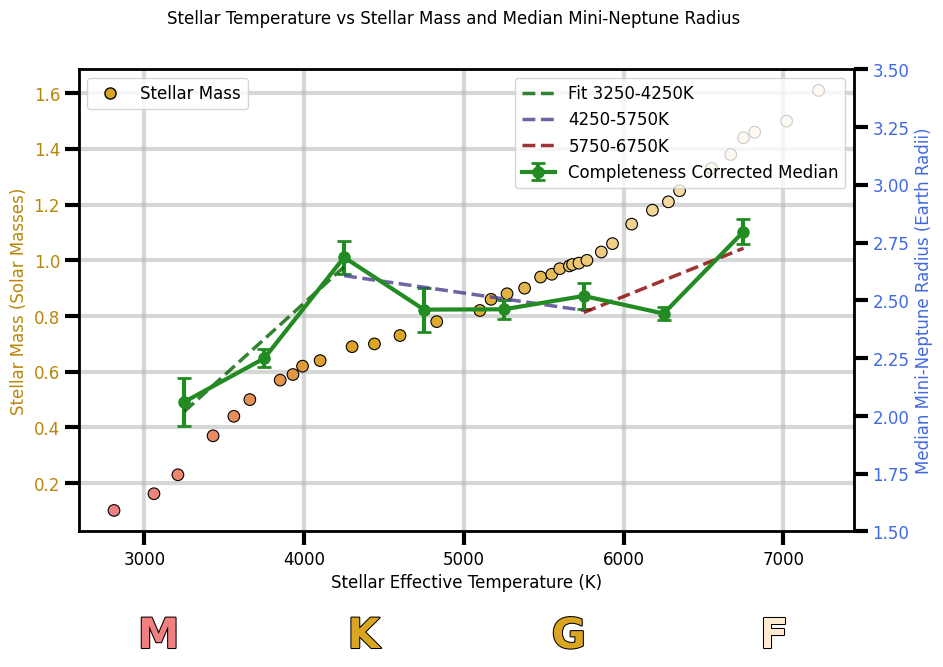

In [64]:
#### PRESENTATION VERSION ####

# Bootstrap error calculation
n_bootstrap = 1000

# Load TOI data for bootstrapping
TOIs = pd.read_csv('../TOI_Mar2025_1pt5to4_R_detected_real_only.csv')
TOIs = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs = TOIs[(TOIs['pl_rade'] > 1.5) & (TOIs['pl_rade'] < 4.0)]
TOIs = TOIs[(TOIs['pl_orbper'] > 0.519) & (TOIs['pl_orbper'] < 30)]
if 'tfopwg_disp' in TOIs.columns:
    TOIs = TOIs[TOIs['tfopwg_disp'] != 'FP']

# Define temperature bins matching mean_median_df
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

planet_radii_medians = []
planet_radii_errors = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    
    if planet_radii_n == 0:
        planet_radii_errors.append(np.nan)
        planet_radii_medians.append(np.nan)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        continue
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_radii.sample(n=planet_radii_n, replace=True)
        bootstrap_medians.append(np.median(bootstrap_sample))
    
    planet_radii_error = np.std(bootstrap_medians)
    planet_radii_median = np.median(planet_radii)
    
    print(f"Teff {bins_teff[i]}-{bins_teff[i+1]} K: N={planet_radii_n}, Median={planet_radii_median:.2f}, Error={planet_radii_error:.3f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(f"\nTotal bins: {len(planet_radii_medians)}, {len(planet_radii_errors)}, {len(bin_centers)}")

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

import matplotlib.colors as mcolors

# Gradual color transition for scatter points
n_points = len(stellar_df)
colors = []
for i in range(n_points):
    ratio = i / (n_points - 1)
    if ratio <= 0.3:
        local_ratio = ratio / 0.3
        r = 240 + (218 - 240) * local_ratio
        g = 128 + (165 - 128) * local_ratio
        b = 128 + (32 - 128) * local_ratio
    else:
        local_ratio = (ratio - 0.3) / 0.7
        r = 218 + (255 - 218) * local_ratio
        g = 165 + (235 - 165) * local_ratio
        b = 32 + (205 - 32) * local_ratio
    colors.append((r/255, g/255, b/255))

from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke
ax1.grid(True, linewidth =3, alpha=.5, zorder=0)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Stellar Mass',
                          markerfacecolor='goldenrod', markeredgecolor='black', markersize=8, linewidth=.1)]
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], 
           c=colors, edgecolor='black', linewidth=0.8, s=70, zorder = 3)
ax1.set_xlabel('Stellar Effective Temperature (K)', size=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', color='darkgoldenrod', size=12)
ax1.tick_params(axis='y', labelcolor='darkgoldenrod')
#ax1.set_ylim(-.00,.07)

# Add colored spectral type labels to the bottom of the plot with black outline
outline = [withStroke(linewidth=1.5, foreground='black')]
xmin, xmax = ax1.get_xlim()
y_bottom = ax1.get_ylim()[0] - .3
x_positions = np.linspace(xmin + 500, xmax - 500, 4)
ax1.text(x_positions[0], y_bottom, 'M', color='lightcoral', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[1], y_bottom, 'K', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[2], y_bottom, 'G', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[3], y_bottom, 'F', color='blanchedalmond', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# Secondary y-axis for Median with error bars
ax2 = ax1.twinx()
# ax2.errorbar(
#     bin_centers, planet_radii_medians, yerr=planet_radii_errors,
#     color='royalblue', label='Median Mini-Neptune Radius', marker='o', 
#     linestyle='-', markersize=8, linewidth=3, capsize=5, capthick=2
#)
ax2.set_ylabel('Median Mini-Neptune Radius (Earth Radii)', color='royalblue', size=12)
ax2.tick_params(axis='y', labelcolor='royalblue', size=12)
ax2.set_ylim(1.5, 3.5)

# Add completeness-corrected medians (green) in the same style
if 'corrected_mean_median_df' in globals():
    ax2.errorbar(
        corrected_mean_median_df['Teff Range Average'],
        corrected_mean_median_df['Weighted Median Radius (Earth Radii)'],
        yerr=corrected_mean_median_df['Weighted Median Error (Earth Radii)'],
        color='forestgreen', label='Completeness Corrected Median',
        marker='o', linestyle='-', markersize=8, linewidth=3,
        capsize=5, capthick=2
    )
    
    # Fit three separate linear segments to the completeness corrected data
    # Remove NaN values for fitting
    x_fit = corrected_mean_median_df['Teff Range Average'].values
    y_fit = corrected_mean_median_df['Weighted Median Radius (Earth Radii)'].values
    
    # Filter out NaN values
    valid_mask = ~(np.isnan(x_fit) | np.isnan(y_fit))
    x_fit_clean = x_fit[valid_mask]
    y_fit_clean = y_fit[valid_mask]
    
    # Define temperature ranges for the three segments
    ranges = [(3250, 4250), (4250, 5750), (5750, 6750)]
    colors_fit = ['darkgreen', 'darkslateblue', 'darkred']
    
    print(f"\n--- Piecewise Linear Fits to Completeness Corrected Median ---")
    
    for idx, (t_min, t_max) in enumerate(ranges):
        # Filter data for this temperature range
        range_mask = (x_fit_clean >= t_min) & (x_fit_clean <= t_max)
        x_range = x_fit_clean[range_mask]
        y_range = y_fit_clean[range_mask]
        
        if len(x_range) >= 2:  # Need at least 2 points for a line
            # Perform linear regression
            coeffs = np.polyfit(x_range, y_range, 1)
            slope, intercept = coeffs
            
            # Generate fitted line
            x_line = np.linspace(x_range.min(), x_range.max(), 50)
            y_line = slope * x_line + intercept
            
            # Plot the fitted line
            label = f'Fit {t_min}-{t_max}K' if idx == 0 else f'{t_min}-{t_max}K'
            ax2.plot(x_line, y_line, color=colors_fit[idx], linestyle='--', 
                     linewidth=2.5, label=label, alpha=0.8)
            
            print(f"\nSegment {idx+1}: {t_min}-{t_max} K")
            print(f"  N points: {len(x_range)}")
            print(f"  Slope: {slope:.4e} R_Earth/K")
            print(f"  Intercept: {intercept:.4f} R_Earth")
            print(f"  Equation: Radius = {slope:.4e} * Teff + {intercept:.4f}")
        else:
            print(f"\nSegment {idx+1}: {t_min}-{t_max} K - Insufficient data points (N={len(x_range)})")


fig.suptitle('Stellar Temperature vs Stellar Mass and Median Mini-Neptune Radius', size=12)
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax1.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax1.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
ax2.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax2.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
for spine in ax1.spines.values():
    spine.set_linewidth(2)
plt.show()

fig.savefig('stellar_temp_vs_disk_mass_and_median_radius.png', dpi=300, bbox_inches='tight')


Teff 3000-3500 K: N=41, Mean=2.42, Error=0.080 R_Earth
Teff 3500-4000 K: N=80, Mean=2.43, Error=0.060 R_Earth
Teff 4000-4500 K: N=75, Mean=2.74, Error=0.057 R_Earth
Teff 4500-5000 K: N=85, Mean=2.72, Error=0.059 R_Earth
Teff 5000-5500 K: N=122, Mean=2.78, Error=0.050 R_Earth
Teff 5500-6000 K: N=168, Mean=2.76, Error=0.043 R_Earth
Teff 6000-6500 K: N=99, Mean=2.77, Error=0.058 R_Earth
Teff 6500-7000 K: N=18, Mean=2.87, Error=0.124 R_Earth

Total bins: 8, 8, 8
Completeness Corrected Teff 3000-3500 K: N=41, Weighted Mean=2.29, Error=0.089 R_Earth
Completeness Corrected Teff 3500-4000 K: N=80, Weighted Mean=2.36, Error=0.059 R_Earth
Completeness Corrected Teff 4000-4500 K: N=75, Weighted Mean=2.70, Error=0.067 R_Earth
Completeness Corrected Teff 4500-5000 K: N=85, Weighted Mean=2.56, Error=0.074 R_Earth
Completeness Corrected Teff 5000-5500 K: N=122, Weighted Mean=2.61, Error=0.053 R_Earth
Completeness Corrected Teff 5500-6000 K: N=168, Weighted Mean=2.64, Error=0.052 R_Earth
Completeness 

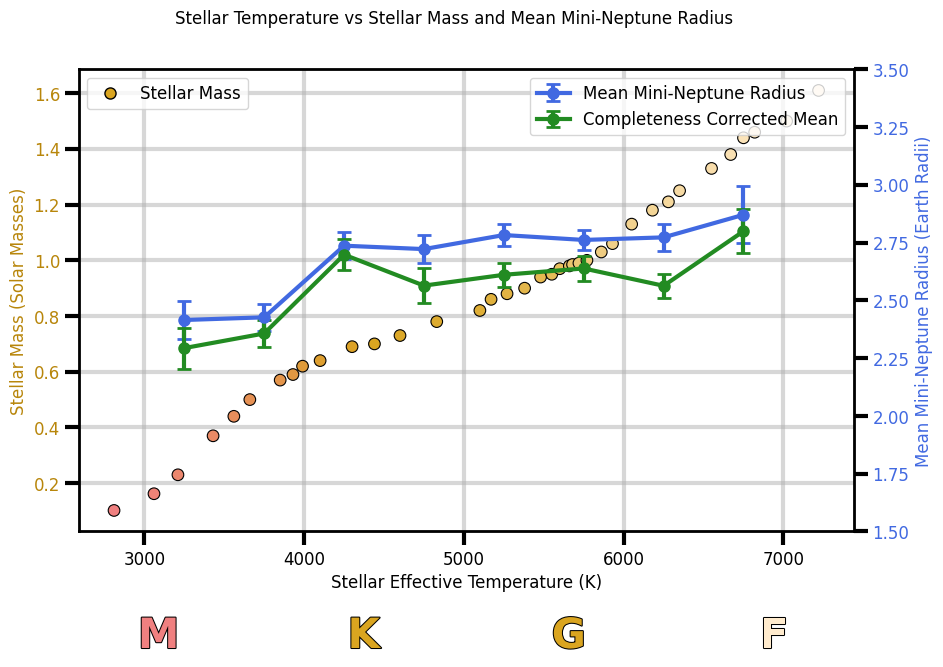

In [65]:
#### PRESENTATION VERSION - USING MEANS ####

# Bootstrap error calculation
n_bootstrap = 1000

# Load TOI data for bootstrapping
TOIs_means = pd.read_csv('../TOI_Mar2025_1pt5to4_R_detected_real_only.csv')
TOIs_means = TOIs_means.dropna(subset=['st_teff', 'pl_rade'])
TOIs_means = TOIs_means[(TOIs_means['pl_rade'] > 1.8) & (TOIs_means['pl_rade'] < 4.0)]
TOIs_means = TOIs_means[(TOIs_means['pl_orbper'] > 0.531) & (TOIs_means['pl_orbper'] < 25.1)]
if 'tfopwg_disp' in TOIs_means.columns:
    TOIs_means = TOIs_means[TOIs_means['tfopwg_disp'] != 'FP']

# Define temperature bins matching mean_median_df
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

planet_radii_means = []
planet_radii_errors = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs_means['st_teff'] >= bins_teff[i]) & (TOIs_means['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs_means.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    
    if planet_radii_n == 0:
        planet_radii_errors.append(np.nan)
        planet_radii_means.append(np.nan)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        continue
    
    # Bootstrap resampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_radii.sample(n=planet_radii_n, replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))
    
    planet_radii_error = np.std(bootstrap_means)
    planet_radii_mean = np.mean(planet_radii)
    
    print(f"Teff {bins_teff[i]}-{bins_teff[i+1]} K: N={planet_radii_n}, Mean={planet_radii_mean:.2f}, Error={planet_radii_error:.3f} R_Earth")
    
    planet_radii_means.append(planet_radii_mean)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(f"\nTotal bins: {len(planet_radii_means)}, {len(planet_radii_errors)}, {len(bin_centers)}")

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

import matplotlib.colors as mcolors

# Gradual color transition for scatter points
n_points = len(stellar_df)
colors = []
for i in range(n_points):
    ratio = i / (n_points - 1)
    if ratio <= 0.3:
        local_ratio = ratio / 0.3
        r = 240 + (218 - 240) * local_ratio
        g = 128 + (165 - 128) * local_ratio
        b = 128 + (32 - 128) * local_ratio
    else:
        local_ratio = (ratio - 0.3) / 0.7
        r = 218 + (255 - 218) * local_ratio
        g = 165 + (235 - 165) * local_ratio
        b = 32 + (205 - 32) * local_ratio
    colors.append((r/255, g/255, b/255))

from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke
ax1.grid(True, linewidth =3, alpha=.5, zorder=0)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Stellar Mass',
                          markerfacecolor='goldenrod', markeredgecolor='black', markersize=8, linewidth=.1)]
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], 
           c=colors, edgecolor='black', linewidth=0.8, s=70, zorder = 3)
ax1.set_xlabel('Stellar Effective Temperature (K)', size=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', color='darkgoldenrod', size=12)
ax1.tick_params(axis='y', labelcolor='darkgoldenrod')

# Add colored spectral type labels to the bottom of the plot with black outline
outline = [withStroke(linewidth=1.5, foreground='black')]
xmin, xmax = ax1.get_xlim()
y_bottom = ax1.get_ylim()[0] - .3
x_positions = np.linspace(xmin + 500, xmax - 500, 4)
ax1.text(x_positions[0], y_bottom, 'M', color='lightcoral', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[1], y_bottom, 'K', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[2], y_bottom, 'G', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[3], y_bottom, 'F', color='blanchedalmond', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# Secondary y-axis for Mean with error bars
ax2 = ax1.twinx()
ax2.errorbar(
    bin_centers, planet_radii_means, yerr=planet_radii_errors,
    color='royalblue', label='Mean Mini-Neptune Radius', marker='o', 
    linestyle='-', markersize=8, linewidth=3, capsize=5, capthick=2
)
ax2.set_ylabel('Mean Mini-Neptune Radius (Earth Radii)', color='royalblue', size=12)
ax2.tick_params(axis='y', labelcolor='royalblue', size=12)
ax2.set_ylim(1.5, 3.5)

# Add completeness-corrected means (green) with bootstrap error bars
if 'radius_medians' in globals():
    # Calculate weighted means for each temperature range with bootstrap errors
    radius_means_df = pd.DataFrame(columns=['Teff Range', 'Weighted Mean Radius (Earth Radii)', 
                                             'Weighted Mean Error', 'Teff Range Average'])
    
    for temp_range in teff_ranges:
        teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
        vals = teff_df['pl_rade'].values
        weights = teff_df['weight'].values
        
        if len(vals) > 0 and weights.sum() > 0:
            weighted_mean = np.average(vals, weights=weights)
            bin_center = (temp_range[0] + temp_range[1]) / 2
            
            # Bootstrap resampling for weighted mean error
            bootstrap_weighted_means = []
            n_planets = len(vals)
            for _ in range(n_bootstrap):
                # Resample with replacement
                indices = np.random.choice(n_planets, size=n_planets, replace=True)
                bootstrap_vals = vals[indices]
                bootstrap_weights = weights[indices]
                if bootstrap_weights.sum() > 0:
                    bootstrap_weighted_mean = np.average(bootstrap_vals, weights=bootstrap_weights)
                    bootstrap_weighted_means.append(bootstrap_weighted_mean)
            
            weighted_mean_error = np.std(bootstrap_weighted_means) if len(bootstrap_weighted_means) > 0 else 0
            
            print(f"Completeness Corrected Teff {temp_range[0]}-{temp_range[1]} K: N={n_planets}, Weighted Mean={weighted_mean:.2f}, Error={weighted_mean_error:.3f} R_Earth")
            
            radius_means_df = pd.concat([
                radius_means_df,
                pd.DataFrame({
                    'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
                    'Weighted Mean Radius (Earth Radii)': [weighted_mean],
                    'Weighted Mean Error': [weighted_mean_error],
                    'Teff Range Average': [bin_center]
                })], ignore_index=True)
    
    if len(radius_means_df) > 0:
        ax2.errorbar(
            radius_means_df['Teff Range Average'],
            radius_means_df['Weighted Mean Radius (Earth Radii)'],
            yerr=radius_means_df['Weighted Mean Error'],
            color='forestgreen', label='Completeness Corrected Mean',
            marker='o', linestyle='-', markersize=8, linewidth=3,
            capsize=5, capthick=2
        )

fig.suptitle('Stellar Temperature vs Stellar Mass and Mean Mini-Neptune Radius', size=12)
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax1.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax1.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
ax2.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax2.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
for spine in ax1.spines.values():
    spine.set_linewidth(2)
plt.show()

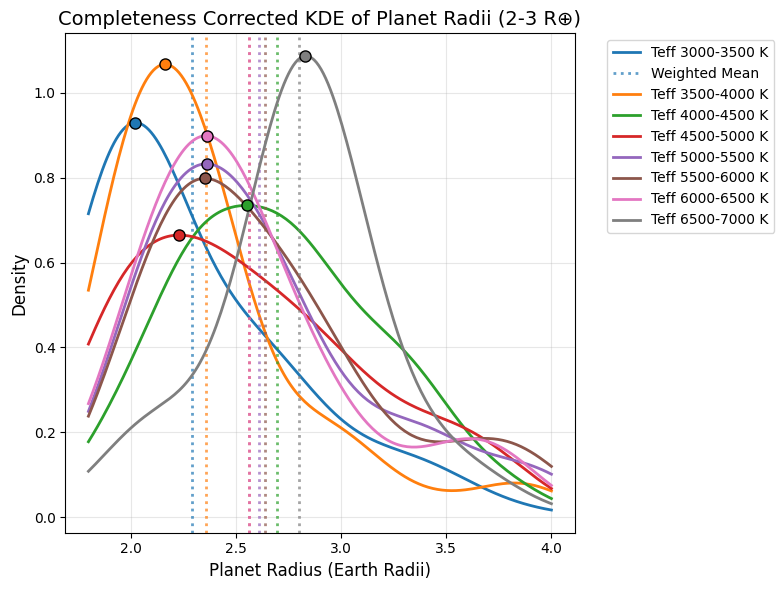

In [66]:
import scipy.stats as stats
from matplotlib.lines import Line2D

# Filter data for radius range 2-4 R_Earth
radius_range = (1.8, 4)
kde_df = merged_df[(merged_df['pl_rade'] >= radius_range[0]) & 
                   (merged_df['pl_rade'] < radius_range[1])].copy()

if len(kde_df) > 0:
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Generate weighted KDE for each temperature range
    for i, temp_range in enumerate(teff_ranges):
        teff_df = kde_df[(kde_df['st_teff'] >= temp_range[0]) & 
                         (kde_df['st_teff'] < temp_range[1])]
        
        if len(teff_df) > 0:
            vals = teff_df['pl_rade'].values
            weights = teff_df['weight'].values
            
            # Normalize weights
            weights_norm = weights / weights.sum()
            
            # Calculate weighted mean
            weighted_mean = np.average(vals, weights=weights)
            
            # Create weighted KDE using gaussian_kde with weights
            kde = stats.gaussian_kde(vals, weights=weights_norm)
            
            # Generate smooth curve
            x_range = np.linspace(radius_range[0], radius_range[1], 200)
            density = kde(x_range)
            
            # Find peak (mode) of the distribution
            peak_idx = np.argmax(density)
            peak_radius = x_range[peak_idx]
            peak_density = density[peak_idx]
            
            # Plot KDE curve (flipped axes)
            color = ax.plot(x_range, density, linewidth=2, 
                   label=f'Teff {temp_range[0]}-{temp_range[1]} K')[0].get_color()
            
            # Add dotted line for weighted mean (only add label for first occurrence)
            mean_label = 'Weighted Mean' if i == 0 else None
            ax.axvline(weighted_mean, linestyle=':', linewidth=2, color=color, 
                      alpha=0.7, label=mean_label)
            
            # Add point for peak of distribution
            ax.plot(peak_radius, peak_density, 'o', color=color, markersize=8, 
                   markeredgecolor='black', markeredgewidth=1, zorder=10)
    
    ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Completeness Corrected KDE of Planet Radii (2-3 R⊕)', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data in radius range 2-4 R_Earth")

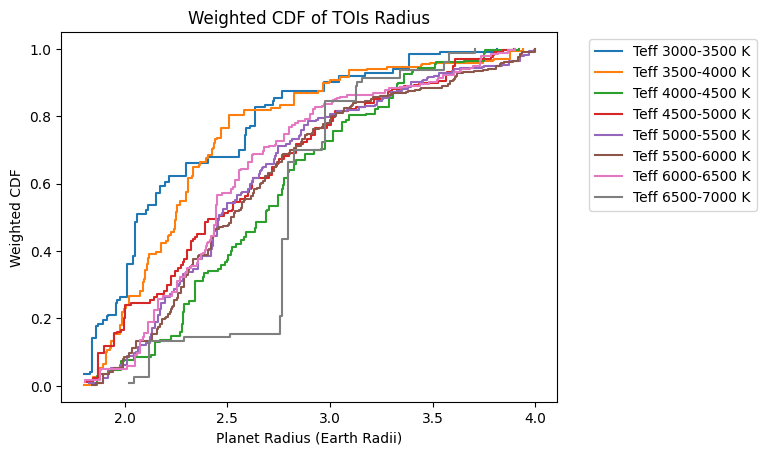

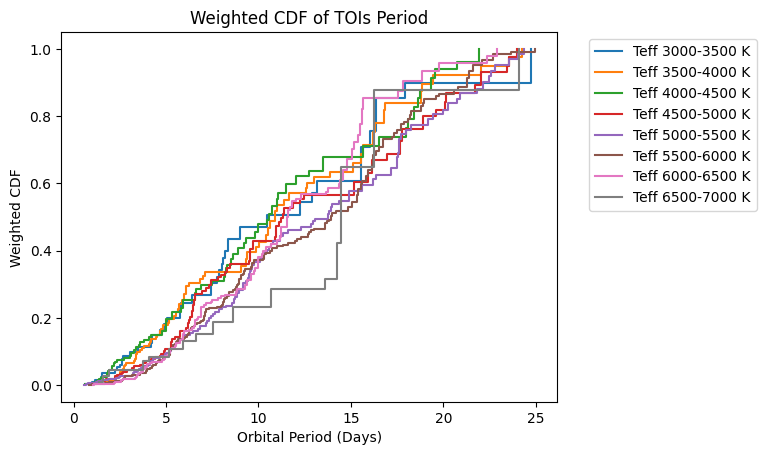

In [67]:
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sort_idx = np.argsort(vals)
        vals_sorted = vals[sort_idx]
        weights_sorted = weights[sort_idx]
        cdf = np.cumsum(weights_sorted) / weights_sorted.sum()
        plt.step(vals_sorted, cdf, where='post', label=f'Teff {temp_range[0]}-{temp_range[1]} K')
plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Weighted CDF')
plt.title('Weighted CDF of TOIs Radius')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sort_idx = np.argsort(vals)
        vals_sorted = vals[sort_idx]
        weights_sorted = weights[sort_idx]
        cdf = np.cumsum(weights_sorted) / weights_sorted.sum()
        plt.step(vals_sorted, cdf, where='post', label=f'Teff {temp_range[0]}-{temp_range[1]} K')
plt.xlabel('Orbital Period (Days)')
plt.ylabel('Weighted CDF')
plt.title('Weighted CDF of TOIs Period')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


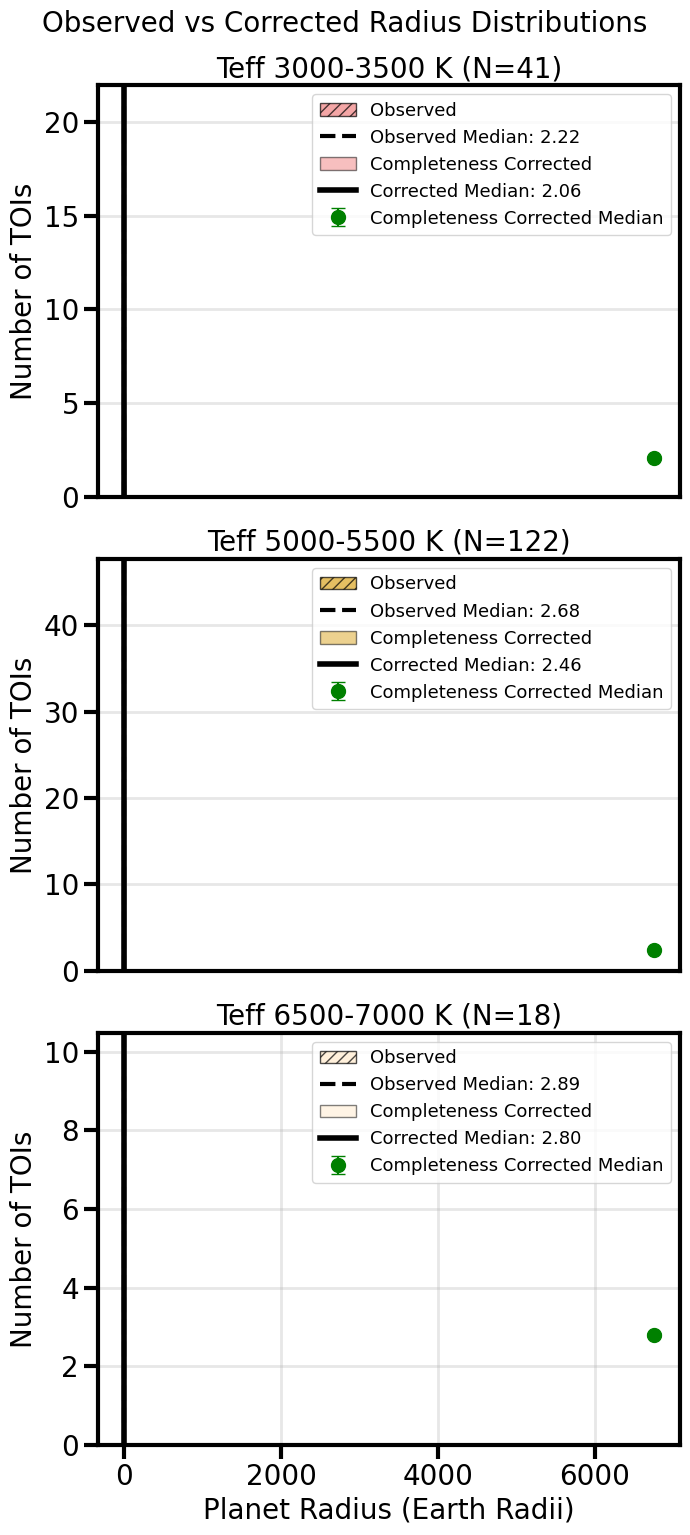

In [68]:
#### COMBINED RADIUS HISTOGRAMS - Three vertical panels ####
fig, axes = plt.subplots(3, 1, figsize=(7, 15))
# Define colors for each temperature range
colors = ['lightcoral', 'goldenrod', 'blanchedalmond']
teff_ranges_subset = [(3000, 3500), (5000, 5500), (6500, 7000)]  # Subset for visualization only
for i, temp_range in enumerate(teff_ranges_subset):
    ax = axes[i]
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]

    if len(teff_df) > 0:
        # Normal histogram (hatched)
        n_normal, bins_normal, patches_normal = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.7, 
            label='Observed', 
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch='///'  # Diagonal hatching for observed
        )

        # Calculate and plot normal median
        normal_median = teff_df['pl_rade'].median()
        ax.axvline(normal_median, linestyle='--', linewidth=3, color='black', 
                  label=f'Observed Median: {normal_median:.2f}')

        # Calculate normalized weights for corrected histogram
        # Scale weights so total weighted count equals total observed count
        weights = teff_df['weight'].values
        total_weight = weights.sum()
        n_observed = len(teff_df)
        normalized_weights = weights * (n_observed / total_weight) if total_weight > 0 else weights

        # Corrected histogram (solid)
        n_corrected, bins_corrected, patches_corrected = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.5, 
            label='Completeness Corrected', 
            weights=normalized_weights,
            color=colors[i],
            edgecolor='black',
            linewidth=1
        )

        # Calculate and plot weighted median (using original weights for median calculation)
        vals = teff_df['pl_rade'].values
        original_weights = teff_df['weight'].values
        if len(vals) > 0 and original_weights.sum() > 0:
            sorted_idx = np.argsort(vals)
            vals_sorted = vals[sorted_idx]
            weights_sorted = original_weights[sorted_idx]
            cumsum = np.cumsum(weights_sorted)
            cutoff = weights_sorted.sum() / 2.0
            weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            ax.axvline(weighted_median, linestyle='-', linewidth=4, color='black', 
                      label=f'Corrected Median: {weighted_median:.2f}')

        # Add completeness corrected radii as points
        if 'radius_medians' in globals():
            # Find the Teff Range string for this bin
            teff_label = f"{temp_range[0]}-{temp_range[1]}K"
            match = radius_medians[radius_medians['Teff Range'] == teff_label]
            if not match.empty:
                corrected_radius = match['Weighted Median Radius (Earth Radii)'].values[0]
                corrected_error = match['Weighted Median Error (Earth Radii)'].values[0] if 'Weighted Median Error (Earth Radii)' in match else None
                bin_center = (temp_range[0] + temp_range[1]) / 2
                ax.errorbar(bin_center, corrected_radius, yerr=corrected_error, fmt='o', color='green', markersize=10, capsize=5, label='Completeness Corrected Median')

    ax.set_ylabel('Number of TOIs', fontsize=20)
    ax.set_title(f'Teff {temp_range[0]}-{temp_range[1]} K (N={len(teff_df)})', fontsize=20)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3, linewidth=2)
    ax.tick_params(axis='both', which='major', width=3, length=10, labelsize=20)
    ax.tick_params(axis='both', which='minor', width=2, length=6, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    if i < 2:
        ax.xaxis.set_ticks([])      # Remove x tick marks for top two panels
        ax.set_xlabel('')           # Remove x axis label for top two panels
    else:
        ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=20)
plt.subplots_adjust(hspace=0)  # Negative hspace to make plots overlap vertically
plt.tight_layout()
plt.suptitle('Observed vs Corrected Radius Distributions', y=1.02, fontsize=20)
plt.show()

# Save the figure to a PNG file
fig.savefig("combined_radius_histograms.png", dpi=300, bbox_inches='tight')

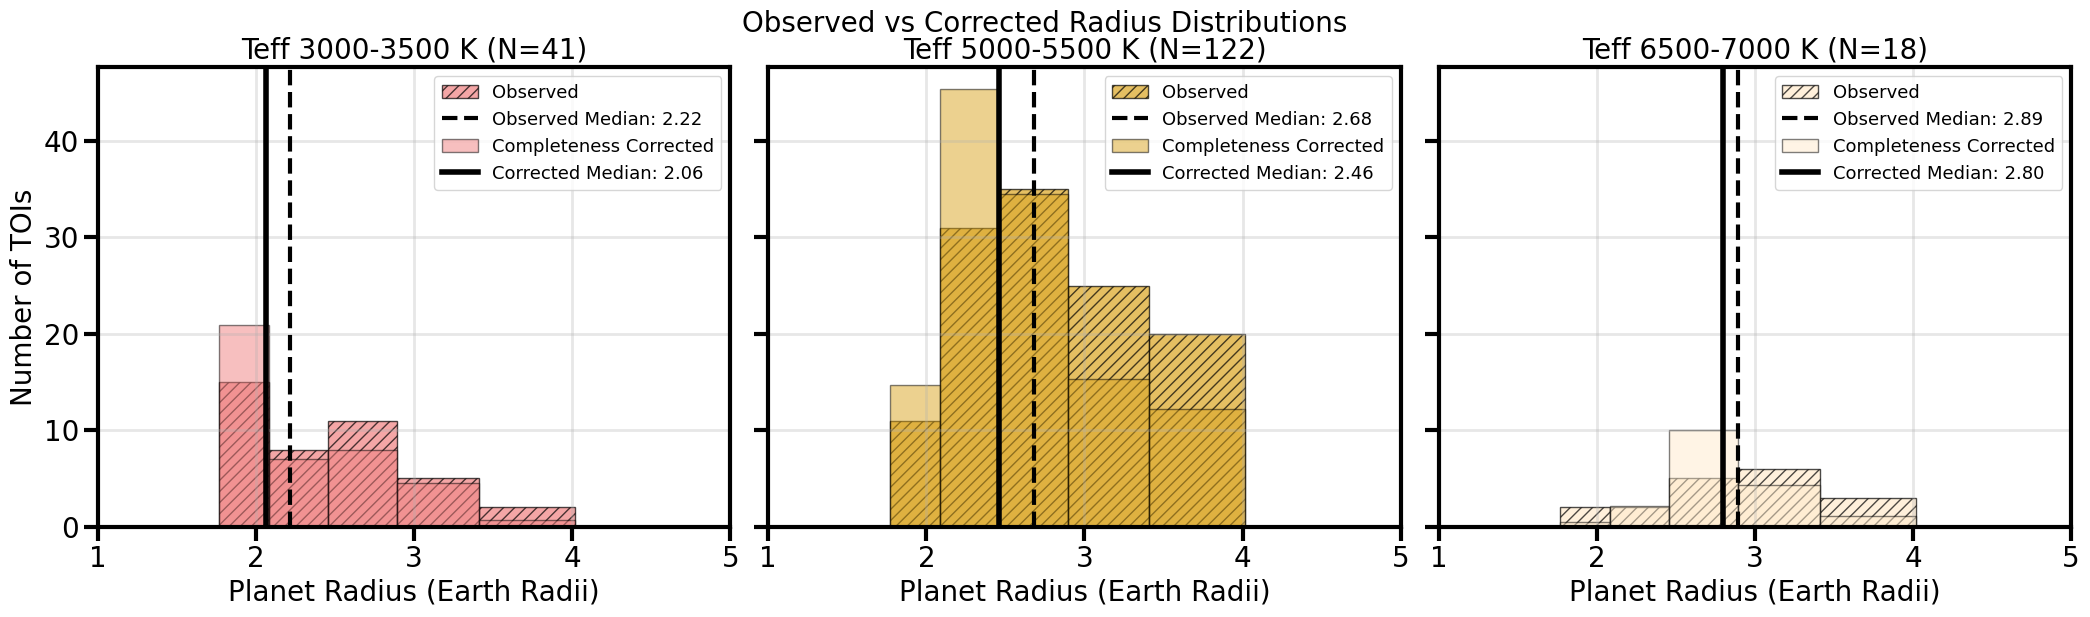

In [69]:
#### COMBINED RADIUS HISTOGRAMS - Three horizontal panels ####
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
# Define colors for each temperature range
colors = ['lightcoral', 'goldenrod', 'blanchedalmond']
teff_ranges_subset = [(3000, 3500), (5000, 5500), (6500, 7000)]  # Subset for visualization only
for i, temp_range in enumerate(teff_ranges_subset):
    ax = axes[i]
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]

    if len(teff_df) > 0:
        # Normal histogram (hatched)
        n_normal, bins_normal, patches_normal = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.7, 
            label='Observed', 
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch='///'  # Diagonal hatching for observed
        )

        # Calculate and plot normal median
        normal_median = teff_df['pl_rade'].median()
        ax.axvline(normal_median, linestyle='--', linewidth=3, color='black', 
                  label=f'Observed Median: {normal_median:.2f}')

        # Calculate normalized weights for corrected histogram
        # Scale weights so total weighted count equals total observed count
        weights = teff_df['weight'].values
        total_weight = weights.sum()
        n_observed = len(teff_df)
        normalized_weights = weights * (n_observed / total_weight) if total_weight > 0 else weights

        # Corrected histogram (solid)
        n_corrected, bins_corrected, patches_corrected = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.5, 
            label='Completeness Corrected', 
            weights=normalized_weights,
            color=colors[i],
            edgecolor='black',
            linewidth=1
        )

        # Calculate and plot weighted median (using original weights for median calculation)
        vals = teff_df['pl_rade'].values
        original_weights = teff_df['weight'].values
        if len(vals) > 0 and original_weights.sum() > 0:
            sorted_idx = np.argsort(vals)
            vals_sorted = vals[sorted_idx]
            weights_sorted = original_weights[sorted_idx]
            cumsum = np.cumsum(weights_sorted)
            cutoff = weights_sorted.sum() / 2.0
            weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            ax.axvline(weighted_median, linestyle='-', linewidth=4, color='black', 
                      label=f'Corrected Median: {weighted_median:.2f}')

    ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=20)
    ax.set_xlim(1, 5.0)
    ax.set_title(f'Teff {temp_range[0]}-{temp_range[1]} K (N={len(teff_df)})', fontsize=20)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3, linewidth=2)
    ax.tick_params(axis='both', which='major', width=3, length=10, labelsize=20)
    ax.tick_params(axis='both', which='minor', width=2, length=6, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    
    # Only show y-axis label on leftmost panel
    if i == 0:
        ax.set_ylabel('Number of TOIs', fontsize=20)

plt.subplots_adjust(wspace=0.05)  # Small spacing between horizontal panels
plt.tight_layout()
plt.suptitle('Observed vs Corrected Radius Distributions', y=1.02, fontsize=20)
plt.show()

# Save the figure to a PNG file
fig.savefig("combined_radius_histograms.png", dpi=300, bbox_inches='tight')